<a href="https://colab.research.google.com/github/shivansh2310/The-Egg-Project/blob/main/Egg_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [2]:
egg_data = pd.read_csv("/content/necc_egg_prices_daily.csv")
egg_data

,date,year,month,day,market,category,price,price_filled,fill_method
0,2009-01-01,2009,1,1,Ahmedabad,NECC,204.0,204.0,observed
1,2009-01-01,2009,1,1,Ajmer,NECC,212.0,212.0,observed
2,2009-01-01,2009,1,1,Asansole,NECC,NaN,500.0,next_price
3,2009-01-01,2009,1,1,Barwala,NECC,NaN,168.0,next_price
4,2009-01-01,2009,1,1,Bengaluru (CC),NECC,195.0,195.0,observed
...,...,...,...,...,...,...,...,...,...
241675,2026-05-31,2026,5,31,Muzaffurpur (CC),PREVAILING,580.0,580.0,observed
241676,2026-05-31,2026,5,31,Nagpur,PREVAILING,600.0,600.0,observed
241677,2026-05-31,2026,5,31,Patna,PREVAILING,580.0,580.0,observed
241678,2026-05-31,2026,5,31,Ranchi (CC),PREVAILING,595.0,595.0,observed


### Data Overview
Let's start by getting a concise summary of the DataFrame using `info()` to see the data types and non-null values, and then display descriptive statistics of the numerical columns using `describe()`.

In [3]:
print(egg_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241680 entries, 0 to 241679
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   date          241680 non-null  object 
 1   year          241680 non-null  int64  
 2   month         241680 non-null  int64  
 3   day           241680 non-null  int64  
 4   market        241680 non-null  object 
 5   category      241680 non-null  object 
 6   price         196859 non-null  float64
 7   price_filled  241680 non-null  float64
 8   fill_method   241680 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 16.6+ MB
None


In [4]:
display(egg_data.describe())

,year,month,day,price,price_filled
count,241680.000000,241680.000000,241680.000000,196859.000000,241680.000000
mean,2017.214308,6.439780,15.726572,388.111979,401.741958
std,5.030466,3.456087,8.798742,111.157820,109.112713
min,2009.000000,1.000000,1.000000,100.000000,100.000000
25%,2013.000000,3.000000,8.000000,305.000000,315.000000
50%,2017.000000,6.000000,16.000000,380.000000,405.000000
75%,2022.000000,9.000000,23.000000,466.000000,490.000000
max,2026.000000,12.000000,31.000000,890.000000,890.000000


### Data Cleaning and Unique Value Check
First, let's convert the 'date' column to datetime objects. Then, we will check the unique values and their counts for key categorical columns to understand the distinct entries within them.

In [5]:
egg_data['date'] = pd.to_datetime(egg_data['date'])
print(f"Date column converted to datetime. New dtype: {egg_data['date'].dtype}")

Date column converted to datetime. New dtype: datetime64[ns]


In [6]:
for column in ['market', 'category', 'fill_method']:
    print(f"\nUnique values in '{column}':")
    print(egg_data[column].value_counts())


Unique values in 'market':
market
Jabalpur            12720
Ajmer                6360
Asansole             6360
Barwala              6360
Ahmedabad            6360
Bengaluru (CC)       6360
Brahmapur (OD)       6360
Chennai (CC)         6360
Burdwan (CC)         6360
Delhi (CC)           6360
E.Godavari           6360
Hospet               6360
Chittoor             6360
Hyderabad            6360
Kolkata (WB)         6360
Ludhiana             6360
Midnapur (KOL)       6360
Mumbai (CC)          6360
Mysuru               6360
Namakkal             6360
Pune                 6360
Raipur               6360
Surat                6360
Vijayawada           6360
Vizag                6360
W.Godavari           6360
Warangal             6360
Allahabad (CC)       6360
Bhopal               6360
Indore (CC)          6360
Kanpur (CC)          6360
Luknow (CC)          6360
Muzaffurpur (CC)     6360
Nagpur               6360
Patna                6360
Ranchi  (CC)         6360
Varanasi (CC)        6360
Nam

### Price Distribution Analysis
Let's visualize the distribution of the `price_filled` column to understand its characteristics using a histogram and a box plot.

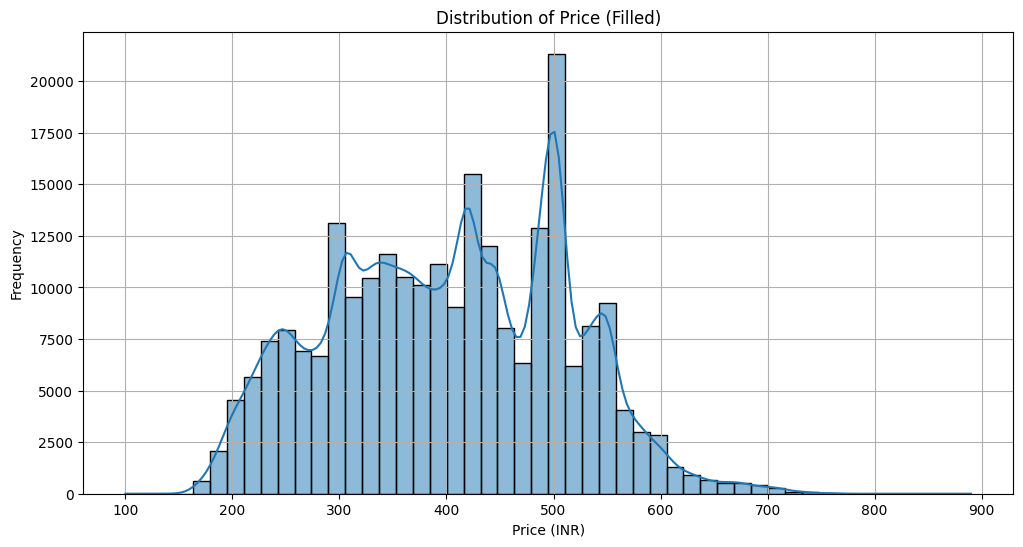

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(egg_data['price_filled'], kde=True, bins=50)
plt.title('Distribution of Price (Filled)')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

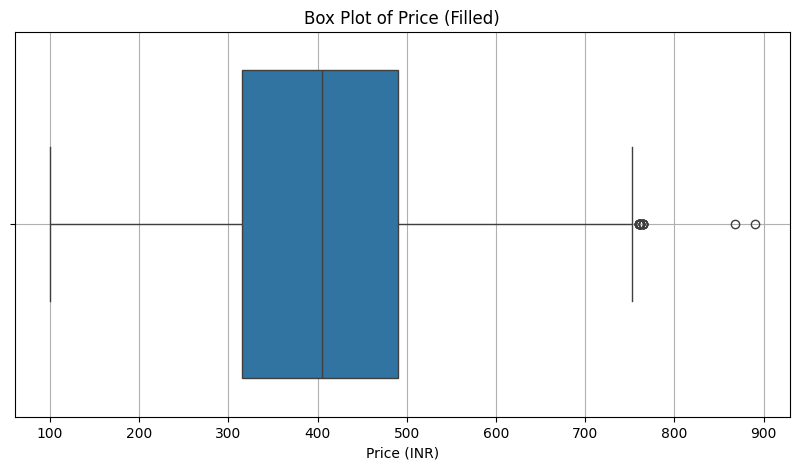

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=egg_data['price_filled'])
plt.title('Box Plot of Price (Filled)')
plt.xlabel('Price (INR)')
plt.grid(True)
plt.show()

### Price Trends Over Time
Let's analyze the average daily egg price over the entire period to observe any overall trends or seasonality.

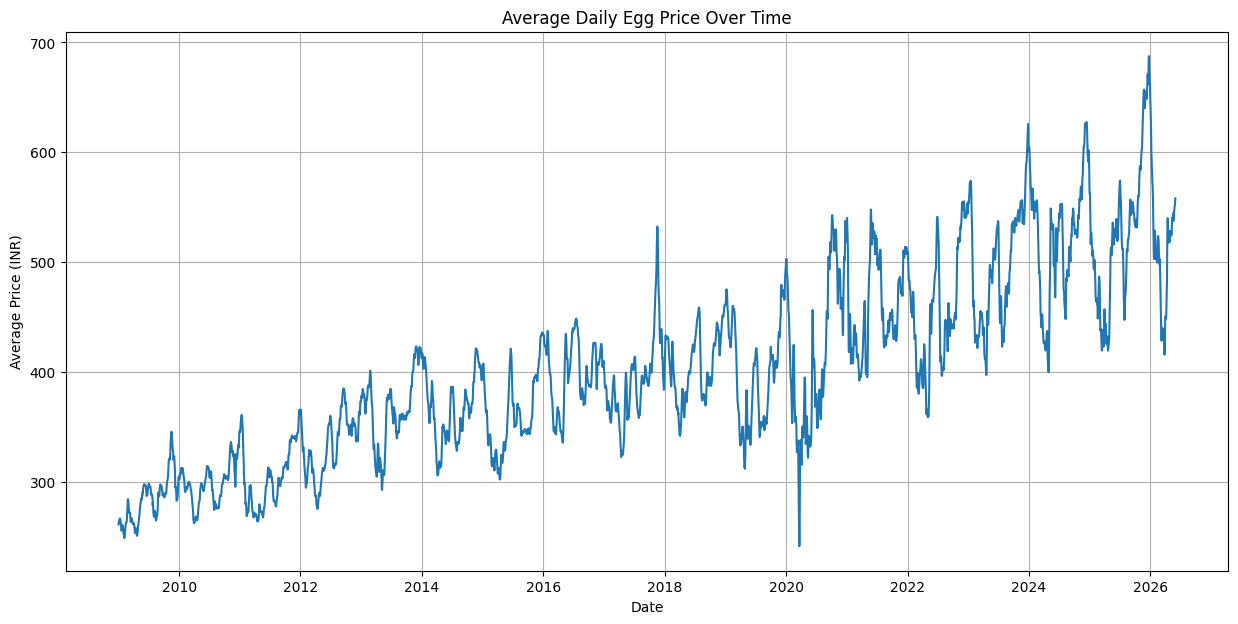

In [9]:
daily_avg_price = egg_data.groupby('date')['price_filled'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=daily_avg_price, x='date', y='price_filled')
plt.title('Average Daily Egg Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price (INR)')
plt.grid(True)
plt.show()

### Monthly and Yearly Price Trends

Let's examine how egg prices vary by month and year to identify any seasonal patterns or long-term trends.

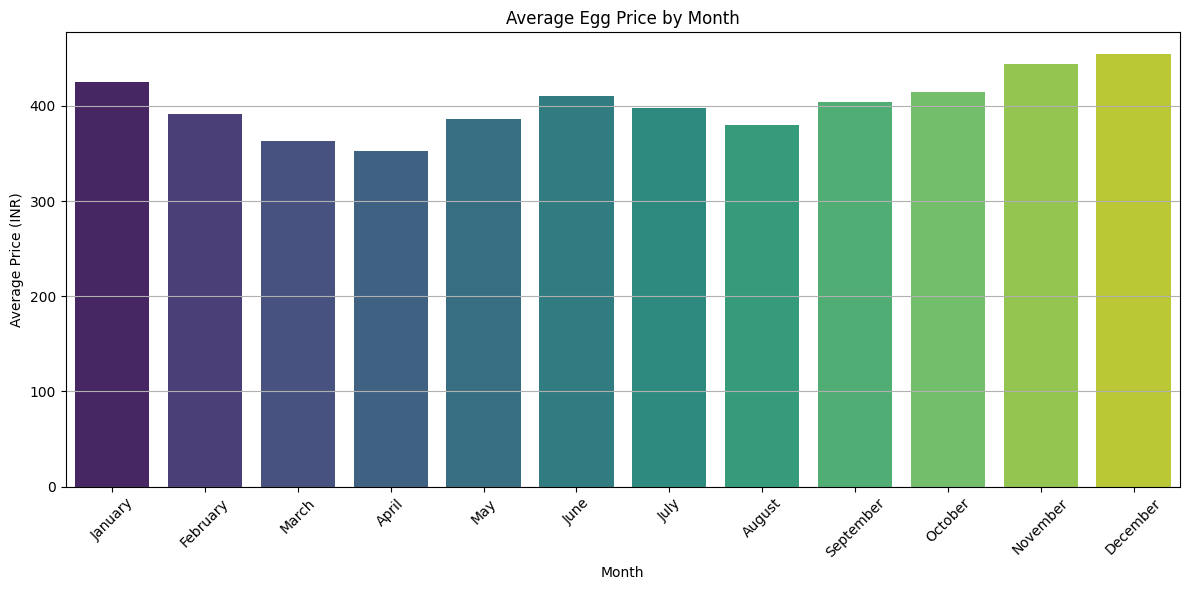

In [18]:
egg_data['month_name'] = egg_data['date'].dt.month_name()
monthly_avg_price = egg_data.groupby('month_name')['price_filled'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='month_name', y='price_filled', data=monthly_avg_price, palette='viridis')
plt.title('Average Egg Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

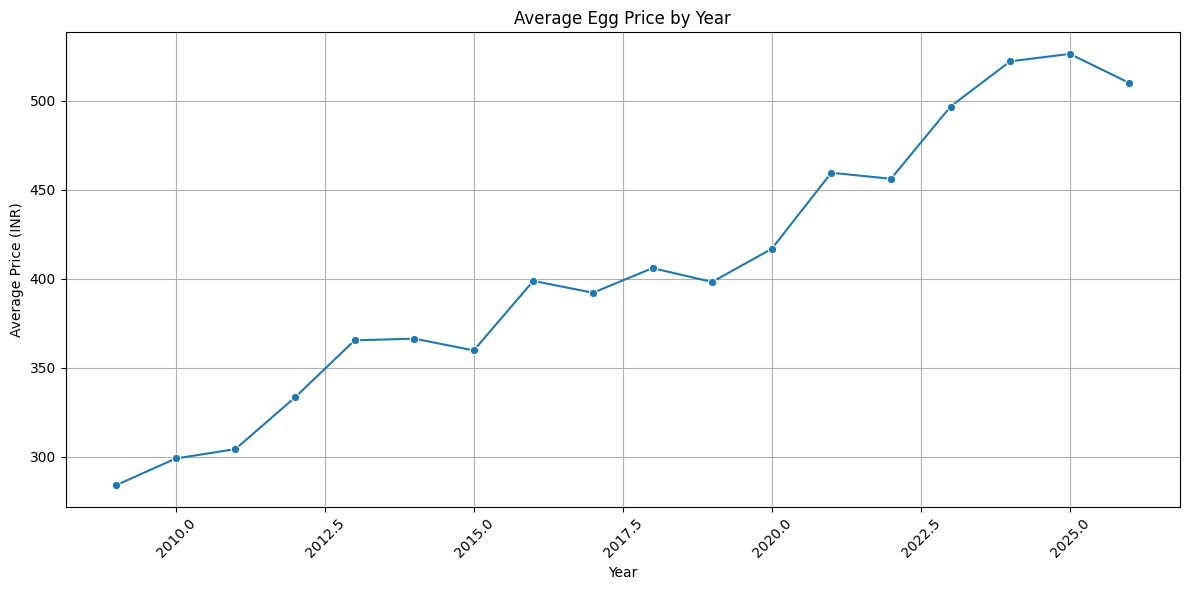

In [19]:
yearly_avg_price = egg_data.groupby('year')['price_filled'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='price_filled', data=yearly_avg_price, marker='o')
plt.title('Average Egg Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Reshaping Data: Market Prices as Columns
To facilitate cross-market price analysis, let's pivot the `egg_data` DataFrame. The 'date' will serve as the index, 'market' names will become new columns, and 'price_filled' will be the values within these new columns. This will give us a wide-format DataFrame where we can compare daily prices across all markets directly.

In [10]:
market_prices_df = egg_data.pivot_table(index='date', columns='market', values='price_filled')
display(market_prices_df.head(5))

market,Ahmedabad,Ajmer,Allahabad (CC),Asansole,Barwala,Bengaluru (CC),Bhopal,Brahmapur (OD),Burdwan (CC),Chennai (CC),...,Patna,Pune,Raipur,Ranchi (CC),Surat,Varanasi (CC),Vijayawada,Vizag,W.Godavari,Warangal
date,,,,,,,,,,,,,,,,,,,,,
2009-01-01,204.0,212.0,198.0,500.0,168.0,195.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,212.0,184.0,200.0,184.0,187.0
2009-01-02,206.0,212.0,198.0,500.0,168.0,195.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,212.0,186.0,200.0,186.0,189.0
2009-01-03,208.0,216.0,198.0,500.0,168.0,197.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,214.0,188.0,200.0,188.0,191.0
2009-01-04,210.0,230.0,198.0,500.0,168.0,198.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,214.0,190.0,202.0,190.0,193.0
2009-01-05,210.0,230.0,198.0,500.0,168.0,198.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,214.0,190.0,202.0,190.0,193.0


In [11]:
market_prices_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6360 entries, 2009-01-01 to 2026-05-31
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Ahmedabad         6360 non-null   float64
 1   Ajmer             6360 non-null   float64
 2   Allahabad (CC)    6360 non-null   float64
 3   Asansole          6360 non-null   float64
 4   Barwala           6360 non-null   float64
 5   Bengaluru (CC)    6360 non-null   float64
 6   Bhopal            6360 non-null   float64
 7   Brahmapur (OD)    6360 non-null   float64
 8   Burdwan (CC)      6360 non-null   float64
 9   Chennai (CC)      6360 non-null   float64
 10  Chittoor          6360 non-null   float64
 11  Delhi (CC)        6360 non-null   float64
 12  E.Godavari        6360 non-null   float64
 13  Hospet            6360 non-null   float64
 14  Hyderabad         6360 non-null   float64
 15  Indore (CC)       6360 non-null   float64
 16  Jabalpur          6360 n

In [12]:
market_prices_df.describe()

market,Ahmedabad,Ajmer,Allahabad (CC),Asansole,Barwala,Bengaluru (CC),Bhopal,Brahmapur (OD),Burdwan (CC),Chennai (CC),...,Patna,Pune,Raipur,Ranchi (CC),Surat,Varanasi (CC),Vijayawada,Vizag,W.Godavari,Warangal
count,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,...,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000
mean,392.353066,358.508569,390.002123,464.097720,356.826494,387.799764,376.942296,374.058648,466.751101,399.209119,...,488.183648,401.103066,376.075629,499.266903,464.983019,402.373035,366.394811,375.890252,364.363836,361.515330
std,108.842006,104.746690,112.329721,45.016986,104.150581,111.555654,105.065137,96.804501,46.576188,111.529913,...,61.189324,115.019521,103.231167,57.471091,59.292455,112.042570,107.692659,103.078440,105.486337,102.150952
min,186.000000,168.000000,186.000000,275.000000,165.000000,170.000000,175.000000,200.000000,275.000000,178.000000,...,257.000000,165.000000,173.000000,286.000000,260.000000,193.000000,165.000000,180.000000,165.000000,169.000000
25%,312.000000,280.000000,305.000000,420.000000,280.000000,304.000000,302.000000,305.000000,420.000000,315.000000,...,486.000000,312.000000,300.000000,500.000000,445.000000,319.000000,285.000000,300.000000,285.000000,287.000000
50%,385.000000,345.000000,378.000000,500.000000,350.000000,375.000000,370.000000,305.000000,504.000000,390.000000,...,486.000000,393.000000,370.000000,500.000000,445.000000,395.000000,358.000000,368.000000,357.000000,353.000000
75%,464.000000,425.000000,467.000000,500.000000,421.000000,460.000000,445.000000,455.000000,504.000000,475.000000,...,486.000000,478.250000,445.000000,500.000000,470.000000,477.000000,440.000000,445.000000,437.000000,423.000000
max,710.000000,708.000000,738.000000,525.000000,703.000000,705.000000,710.000000,720.000000,575.000000,710.000000,...,765.000000,740.000000,701.000000,762.000000,715.000000,750.000000,720.000000,702.000000,695.000000,677.000000


### Price Trends for Specific Markets
Let's compare the price trends for 'Delhi (CC)' and 'Mumbai (CC)' to see how these major markets behave over time.

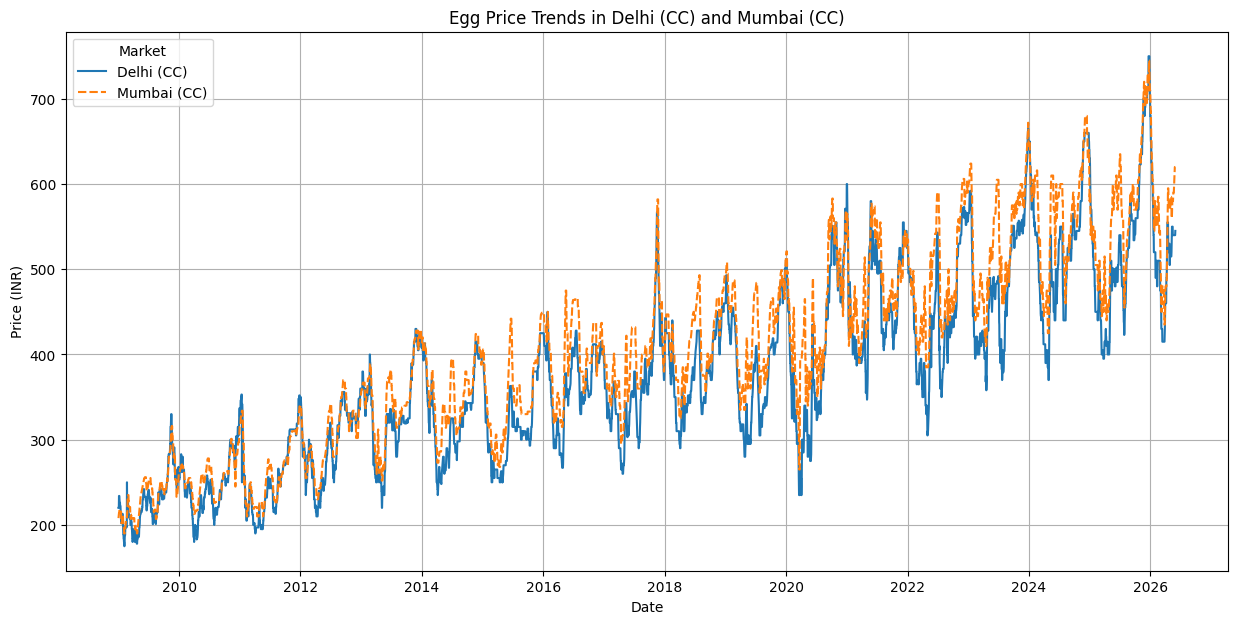

In [13]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=market_prices_df[['Delhi (CC)', 'Mumbai (CC)']])
plt.title('Egg Price Trends in Delhi (CC) and Mumbai (CC)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend(title='Market')
plt.grid(True)
plt.show()

### Correlation Matrix of Market Prices
To understand how prices in different markets move together, let's compute the correlation matrix. A high positive correlation indicates that prices in those markets tend to increase and decrease together.

In [14]:
correlation_matrix = market_prices_df.corr()
display(correlation_matrix.head())

market,Ahmedabad,Ajmer,Allahabad (CC),Asansole,Barwala,Bengaluru (CC),Bhopal,Brahmapur (OD),Burdwan (CC),Chennai (CC),...,Patna,Pune,Raipur,Ranchi (CC),Surat,Varanasi (CC),Vijayawada,Vizag,W.Godavari,Warangal
market,,,,,,,,,,,,,,,,,,,,,
Ahmedabad,1.000000,0.979758,0.989094,-0.613362,0.979972,0.983977,0.989485,0.844977,-0.623549,0.977482,...,0.471362,0.991153,0.988765,0.431585,0.699448,0.988886,0.991306,0.988146,0.991835,0.991077
Ajmer,0.979758,1.000000,0.989744,-0.566595,0.995253,0.953520,0.986036,0.849823,-0.576604,0.942325,...,0.549434,0.968443,0.977259,0.506938,0.733314,0.989112,0.976247,0.968661,0.977363,0.973481
Allahabad (CC),0.989094,0.989744,1.000000,-0.598376,0.989797,0.973389,0.990824,0.858435,-0.609270,0.965277,...,0.518919,0.983750,0.986342,0.476065,0.722370,0.993810,0.987067,0.982075,0.987641,0.983825
Asansole,-0.613362,-0.566595,-0.598376,1.000000,-0.561972,-0.625809,-0.571430,-0.719217,0.994687,-0.635103,...,0.143407,-0.622175,-0.601345,0.197260,-0.196551,-0.599327,-0.626243,-0.636922,-0.619224,-0.596778
Barwala,0.979972,0.995253,0.989797,-0.561972,1.000000,0.953080,0.985351,0.838940,-0.571702,0.941831,...,0.542655,0.968532,0.977960,0.500881,0.720310,0.992320,0.977381,0.969242,0.978756,0.973772


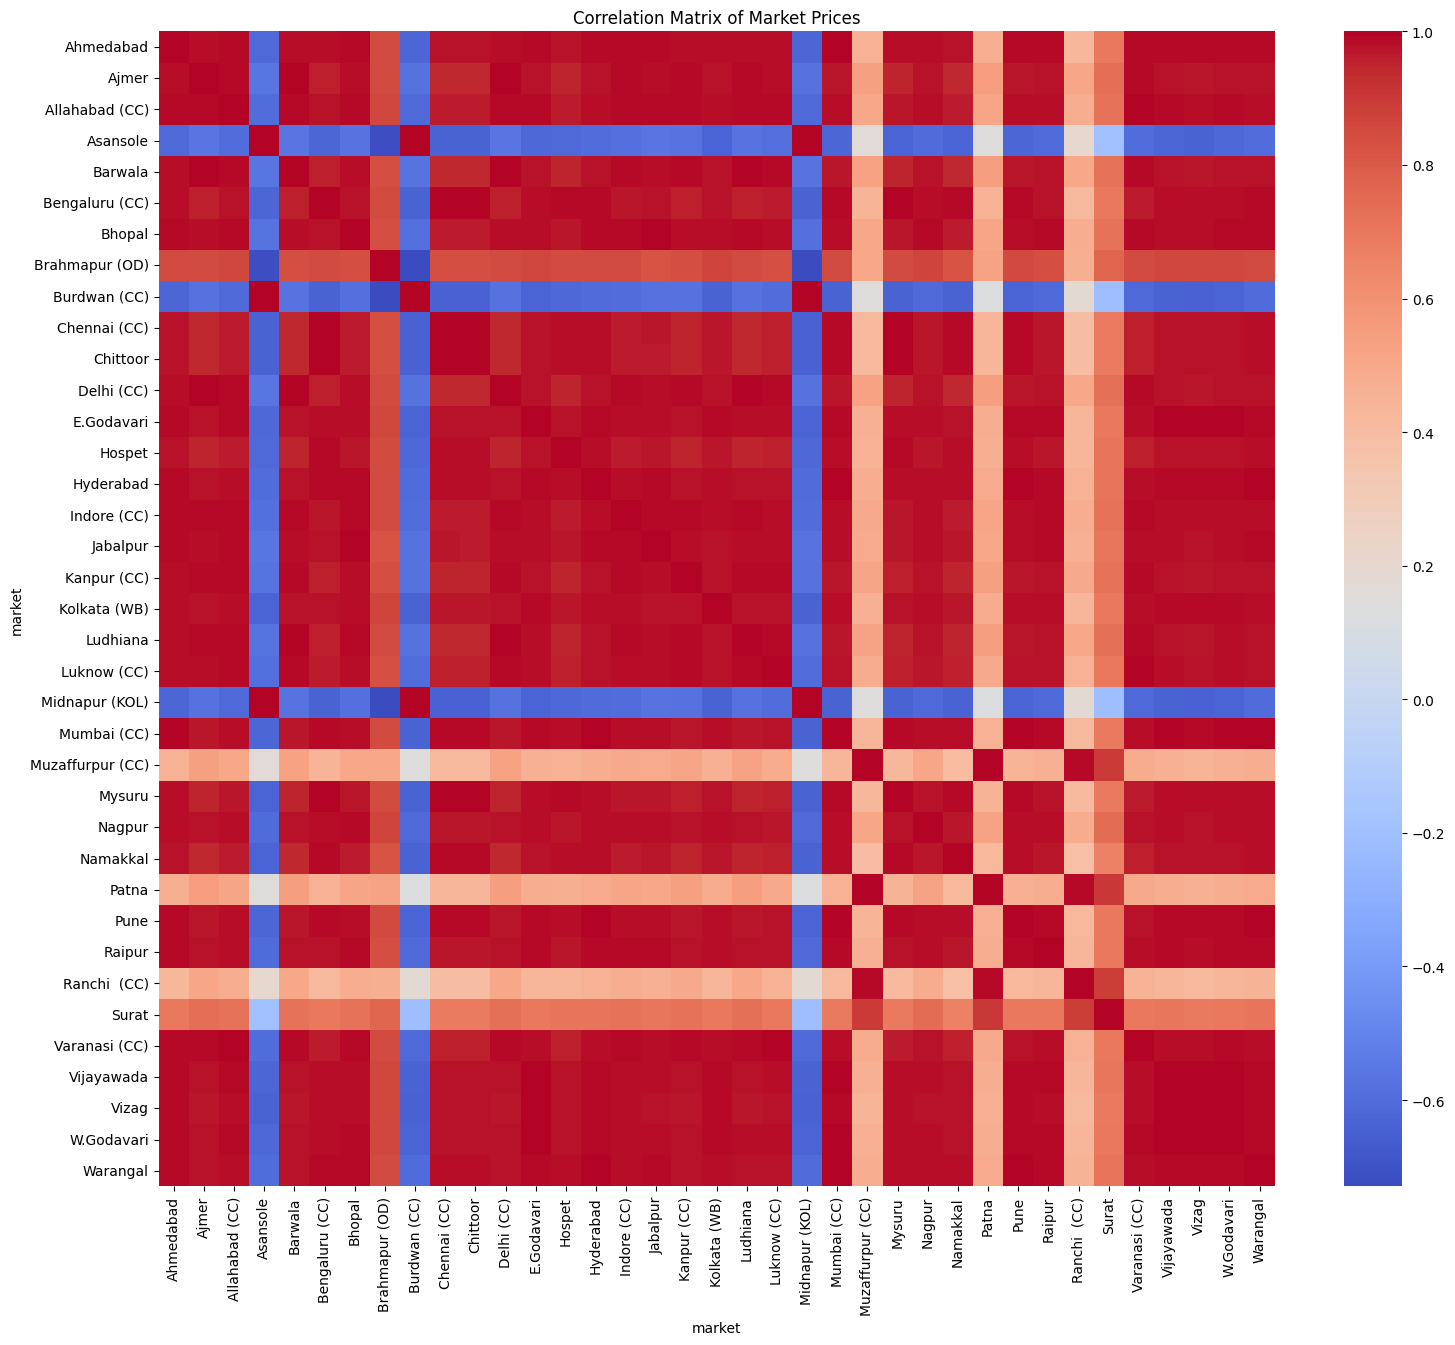

In [15]:
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Market Prices')
plt.show()

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# Calculate the distance matrix from the correlation matrix
# Using 1 - correlation as a distance measure
distance_matrix = 1 - correlation_matrix

# Perform hierarchical clustering
# 'ward' method minimizes the variance within each cluster
linked = linkage(distance_matrix, method='ward')

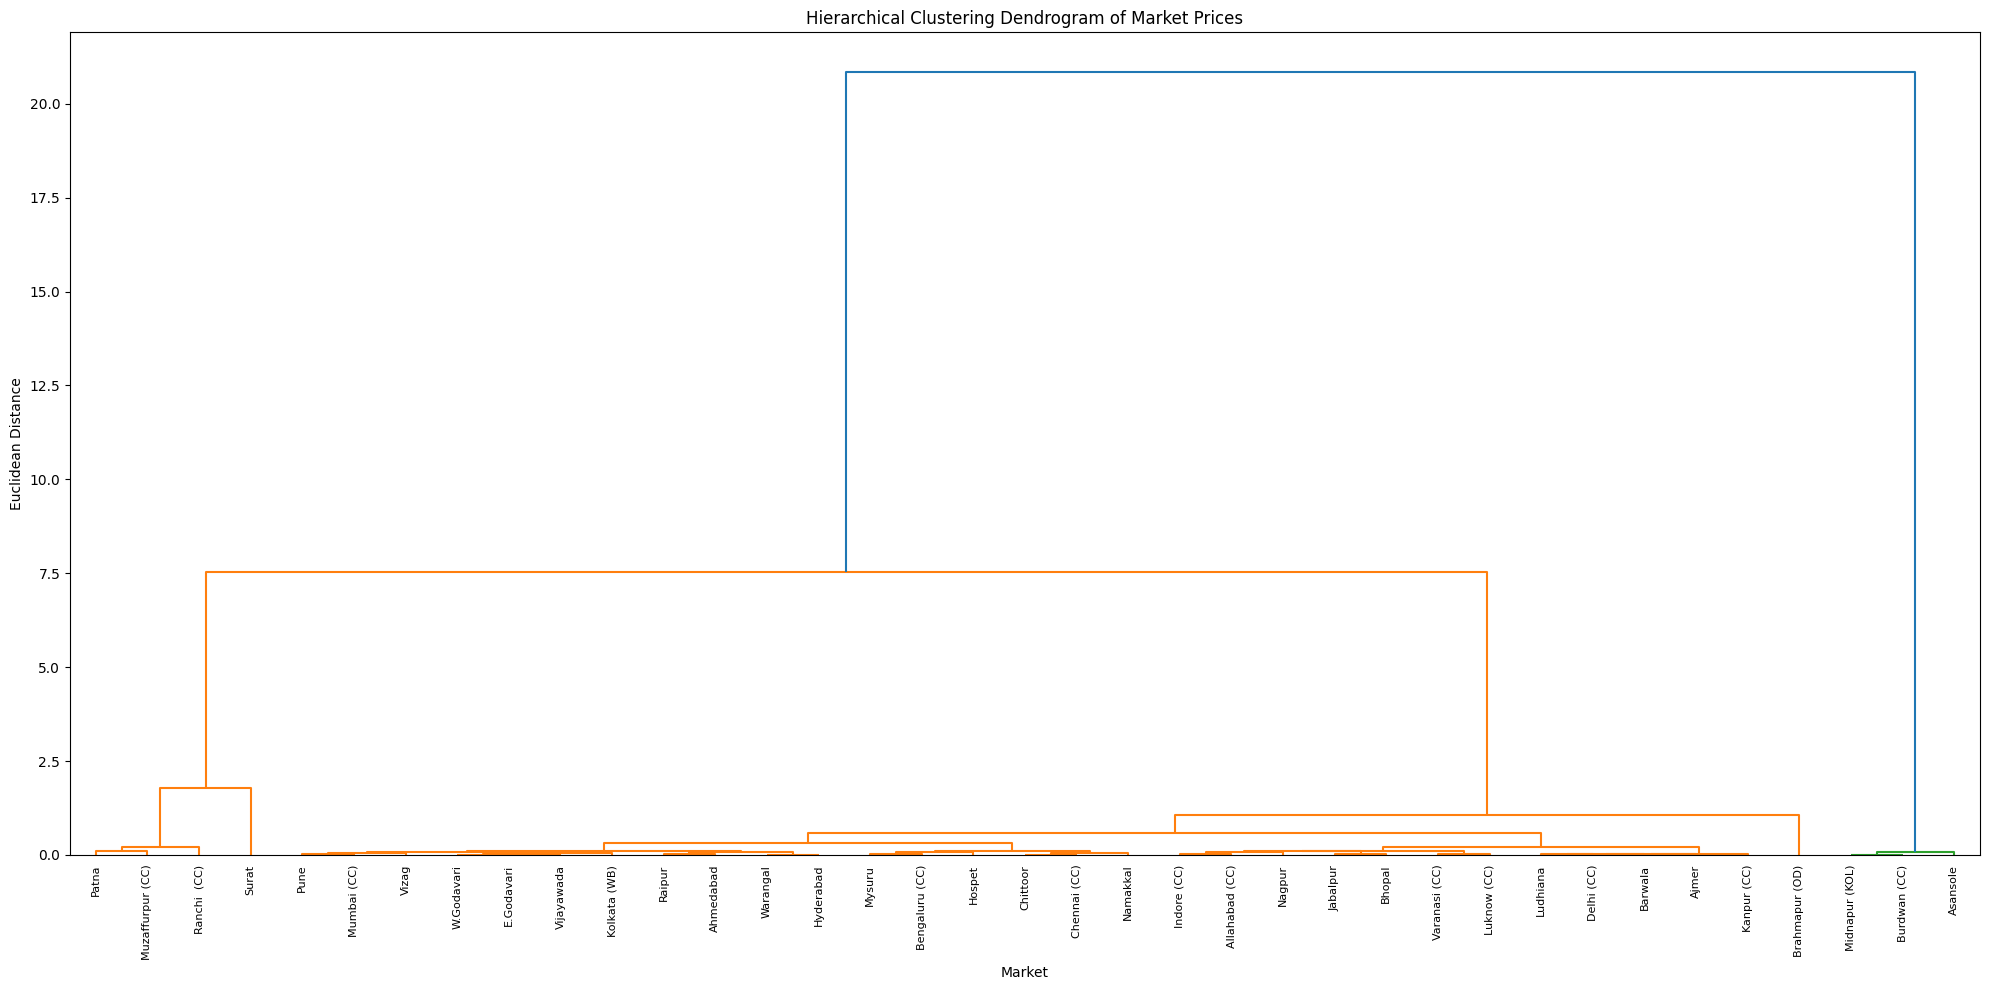

In [17]:
plt.figure(figsize=(20, 10))
dendrogram(
    linked,
    orientation='top',
    labels=correlation_matrix.columns.tolist(), # Use market names as labels
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram of Market Prices')
plt.xlabel('Market')
plt.ylabel('Euclidean Distance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Average Price per Market

Let's calculate the average egg price for each market over the entire period to identify markets with consistently higher or lower prices.

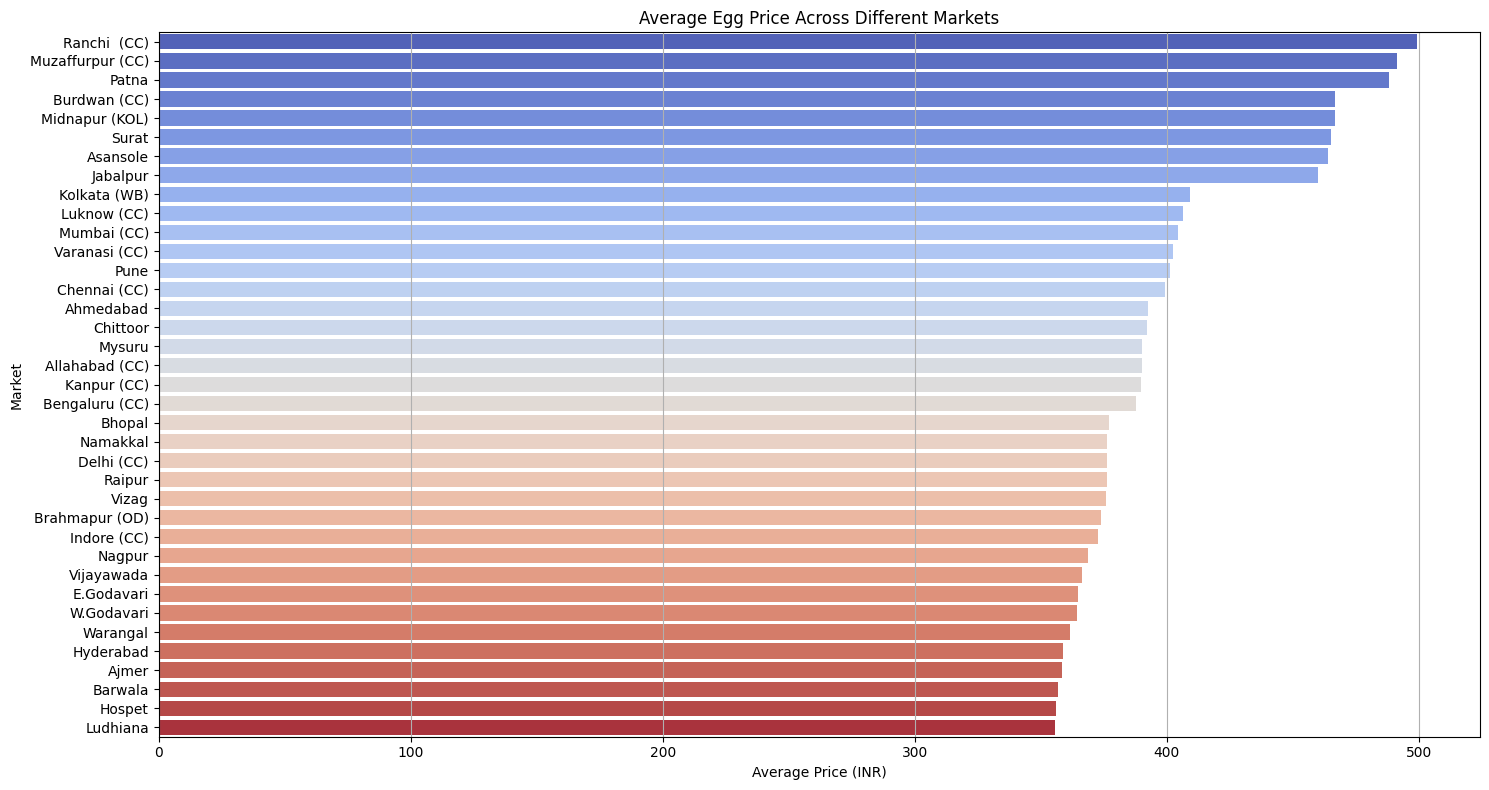

In [35]:
avg_price_per_market = market_prices_df.mean(axis=0).sort_values(ascending=False).reset_index()
avg_price_per_market.columns = ['market', 'price_filled'] # Rename columns for consistency with plotting code

plt.figure(figsize=(15, 8))
sns.barplot(x='price_filled', y='market', data=avg_price_per_market, palette='coolwarm')
plt.title('Average Egg Price Across Different Markets')
plt.xlabel('Average Price (INR)')
plt.ylabel('Market')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Price Volatility per Market

Beyond average prices, understanding the volatility of prices in each market can provide insights into their stability. Let's calculate the standard deviation of prices for each market.

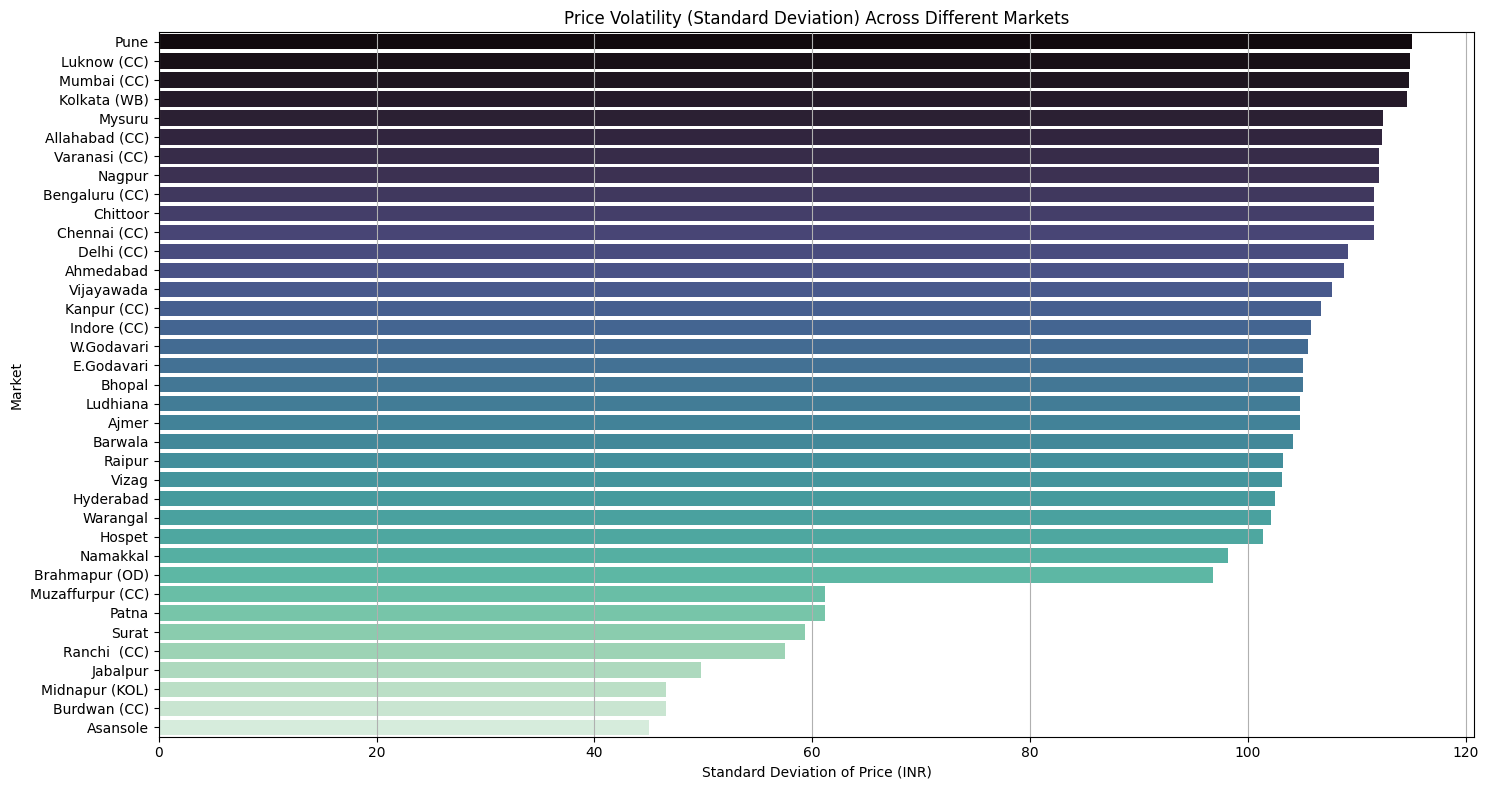

In [37]:
std_dev_price_per_market = market_prices_df.std().sort_values(ascending=False).reset_index()
std_dev_price_per_market.columns = ['market', 'price_filled'] # Rename columns for consistency with plotting code

plt.figure(figsize=(15, 8))
sns.barplot(x='price_filled', y='market', data=std_dev_price_per_market, palette='mako')
plt.title('Price Volatility (Standard Deviation) Across Different Markets')
plt.xlabel('Standard Deviation of Price (INR)')
plt.ylabel('Market')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Top and Bottom Markets by Average Price

Let's extract and display the markets with the highest and lowest average egg prices.

In [38]:
print('Top 5 Markets by Average Price:')
display(avg_price_per_market.head(5))

print('\nBottom 5 Markets by Average Price:')
display(avg_price_per_market.tail(5))

Top 5 Markets by Average Price:


,market,price_filled
0,Ranchi (CC),499.266903
1,Muzaffurpur (CC),491.160692
2,Patna,488.183648
3,Burdwan (CC),466.751101
4,Midnapur (KOL),466.682233



Bottom 5 Markets by Average Price:


,market,price_filled
32,Hyderabad,358.848506
33,Ajmer,358.508569
34,Barwala,356.826494
35,Hospet,356.061164
36,Ludhiana,355.734670


### Top and Bottom Markets by Price Volatility

Now, let's identify the markets that experienced the most and least price fluctuations.

In [39]:
print('Top 5 Markets by Price Volatility (Standard Deviation):')
display(std_dev_price_per_market.head(5))

print('\nBottom 5 Markets by Price Volatility (Standard Deviation):')
display(std_dev_price_per_market.tail(5))

Top 5 Markets by Price Volatility (Standard Deviation):


,market,price_filled
0,Pune,115.019521
1,Luknow (CC),114.862930
2,Mumbai (CC),114.770734
3,Kolkata (WB),114.593047
4,Mysuru,112.386789



Bottom 5 Markets by Price Volatility (Standard Deviation):


,market,price_filled
32,Ranchi (CC),57.471091
33,Jabalpur,49.763003
34,Midnapur (KOL),46.595955
35,Burdwan (CC),46.576188
36,Asansole,45.016986


### Price Trends for Top 5 and Bottom 5 Markets (by Average Price)

Let's visualize the daily price trends for the markets identified as having the highest and lowest average prices.

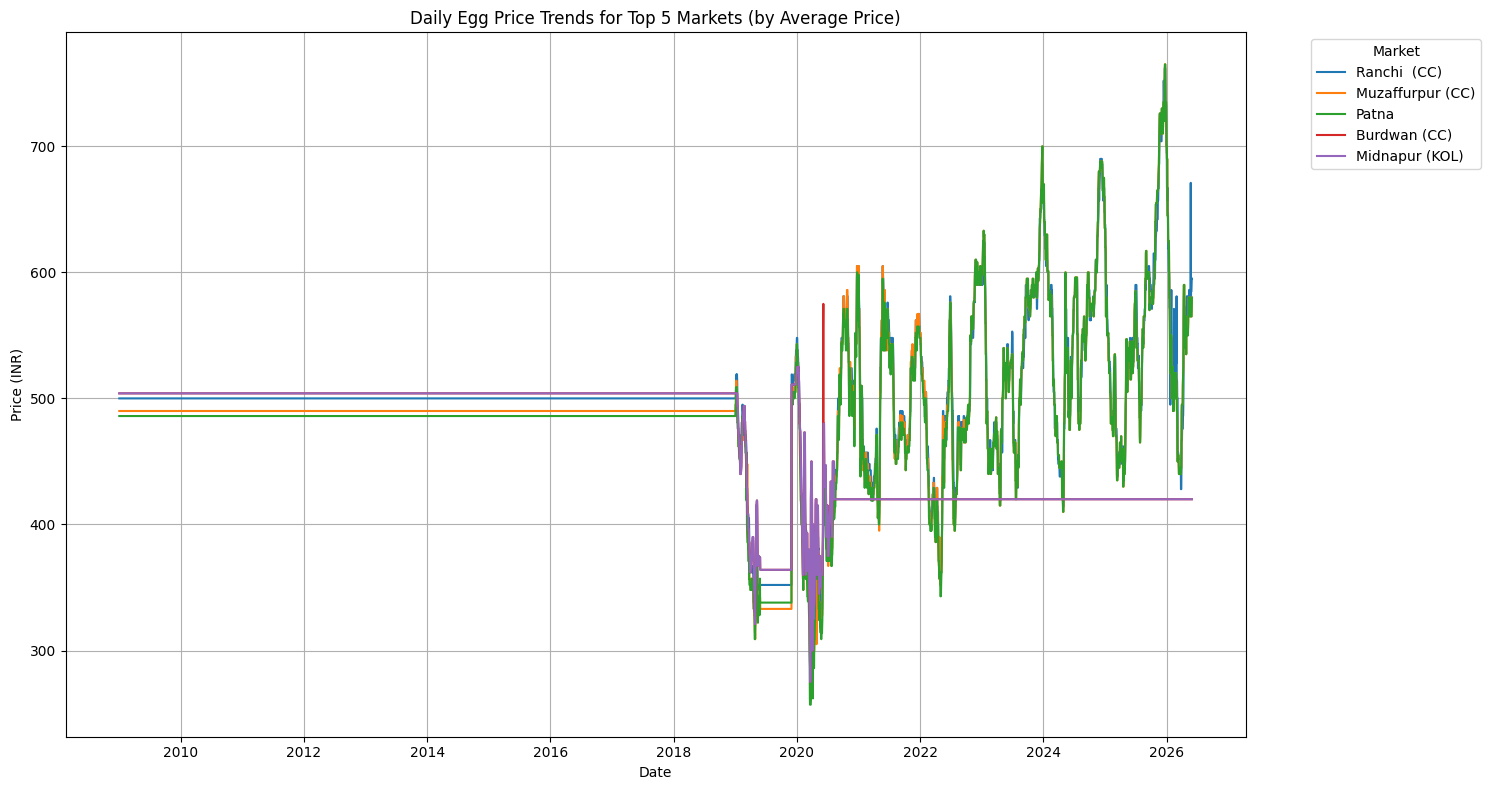

In [41]:
# Get top 5 and bottom 5 markets by average price
top_5_markets = avg_price_per_market['market'].head(5).tolist()
bottom_5_markets = avg_price_per_market['market'].tail(5).tolist()

# Filter market_prices_df for top 5 markets and melt for plotting
top_5_markets_data_melted = market_prices_df[top_5_markets].reset_index().melt(id_vars='date', var_name='market', value_name='price_filled')

# Plot price trends for top 5 markets
plt.figure(figsize=(15, 8))
sns.lineplot(data=top_5_markets_data_melted, x='date', y='price_filled', hue='market')
plt.title('Daily Egg Price Trends for Top 5 Markets (by Average Price)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend(title='Market', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

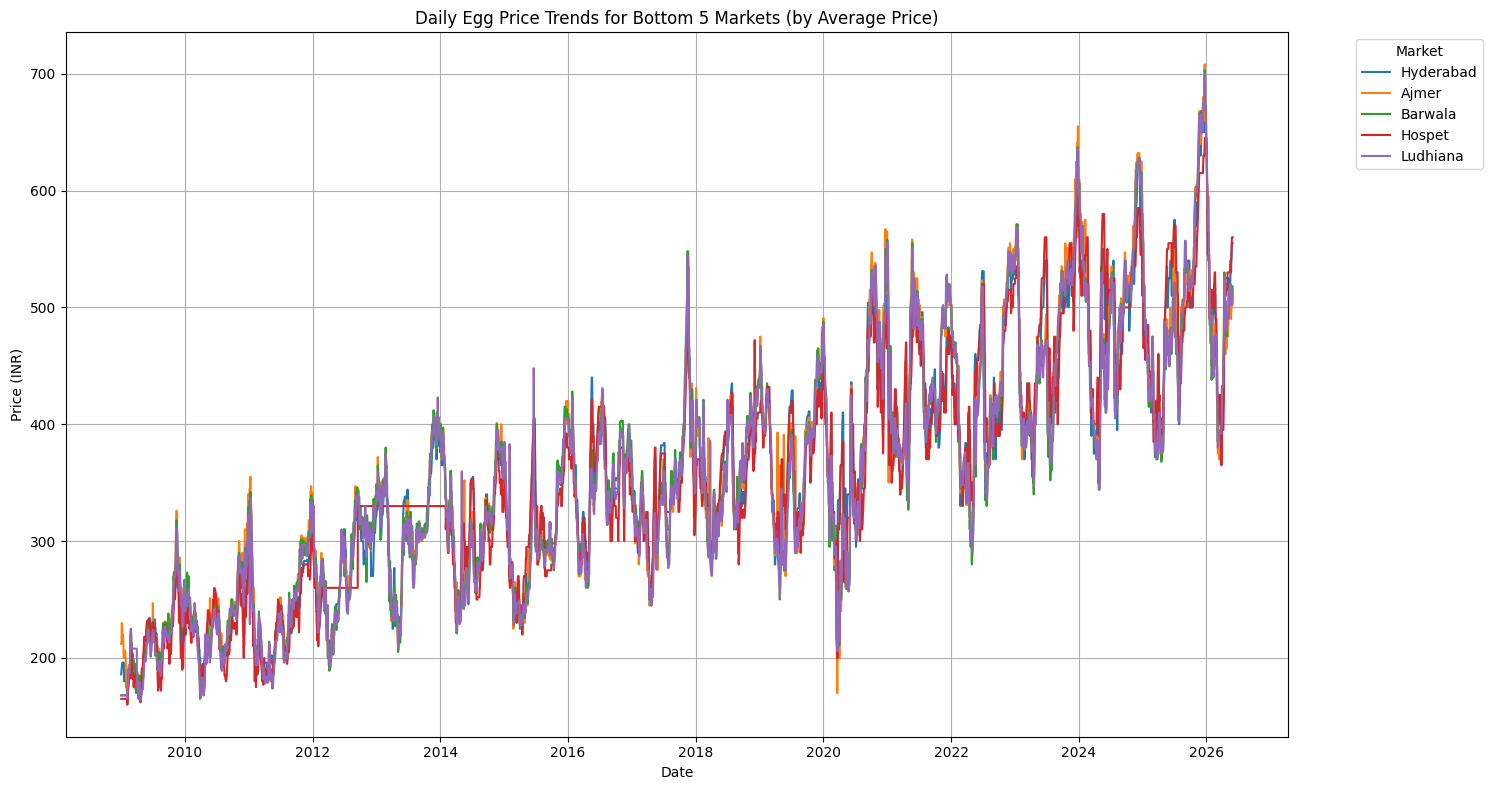

In [42]:
# Filter market_prices_df for bottom 5 markets and melt for plotting
bottom_5_markets_data_melted = market_prices_df[bottom_5_markets].reset_index().melt(id_vars='date', var_name='market', value_name='price_filled')

# Plot price trends for bottom 5 markets
plt.figure(figsize=(15, 8))
sns.lineplot(data=bottom_5_markets_data_melted, x='date', y='price_filled', hue='market')
plt.title('Daily Egg Price Trends for Bottom 5 Markets (by Average Price)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend(title='Market', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Price Trends for Selected Market Clusters

Let's cut the hierarchical clustering dendrogram at a certain threshold to identify distinct market clusters and then visualize the price trends for markets within one or more of these clusters.

Number of clusters formed with threshold 0.25: 7


,market,cluster
3,Asansole,1
8,Burdwan (CC),1
21,Midnapur (KOL),1
2,Allahabad (CC),2
6,Bhopal,2



Markets in the largest cluster (Cluster 2): ['Ajmer', 'Allahabad (CC)', 'Barwala', 'Bhopal', 'Delhi (CC)', 'Indore (CC)', 'Jabalpur', 'Kanpur (CC)', 'Ludhiana', 'Luknow (CC)', 'Nagpur', 'Varanasi (CC)']


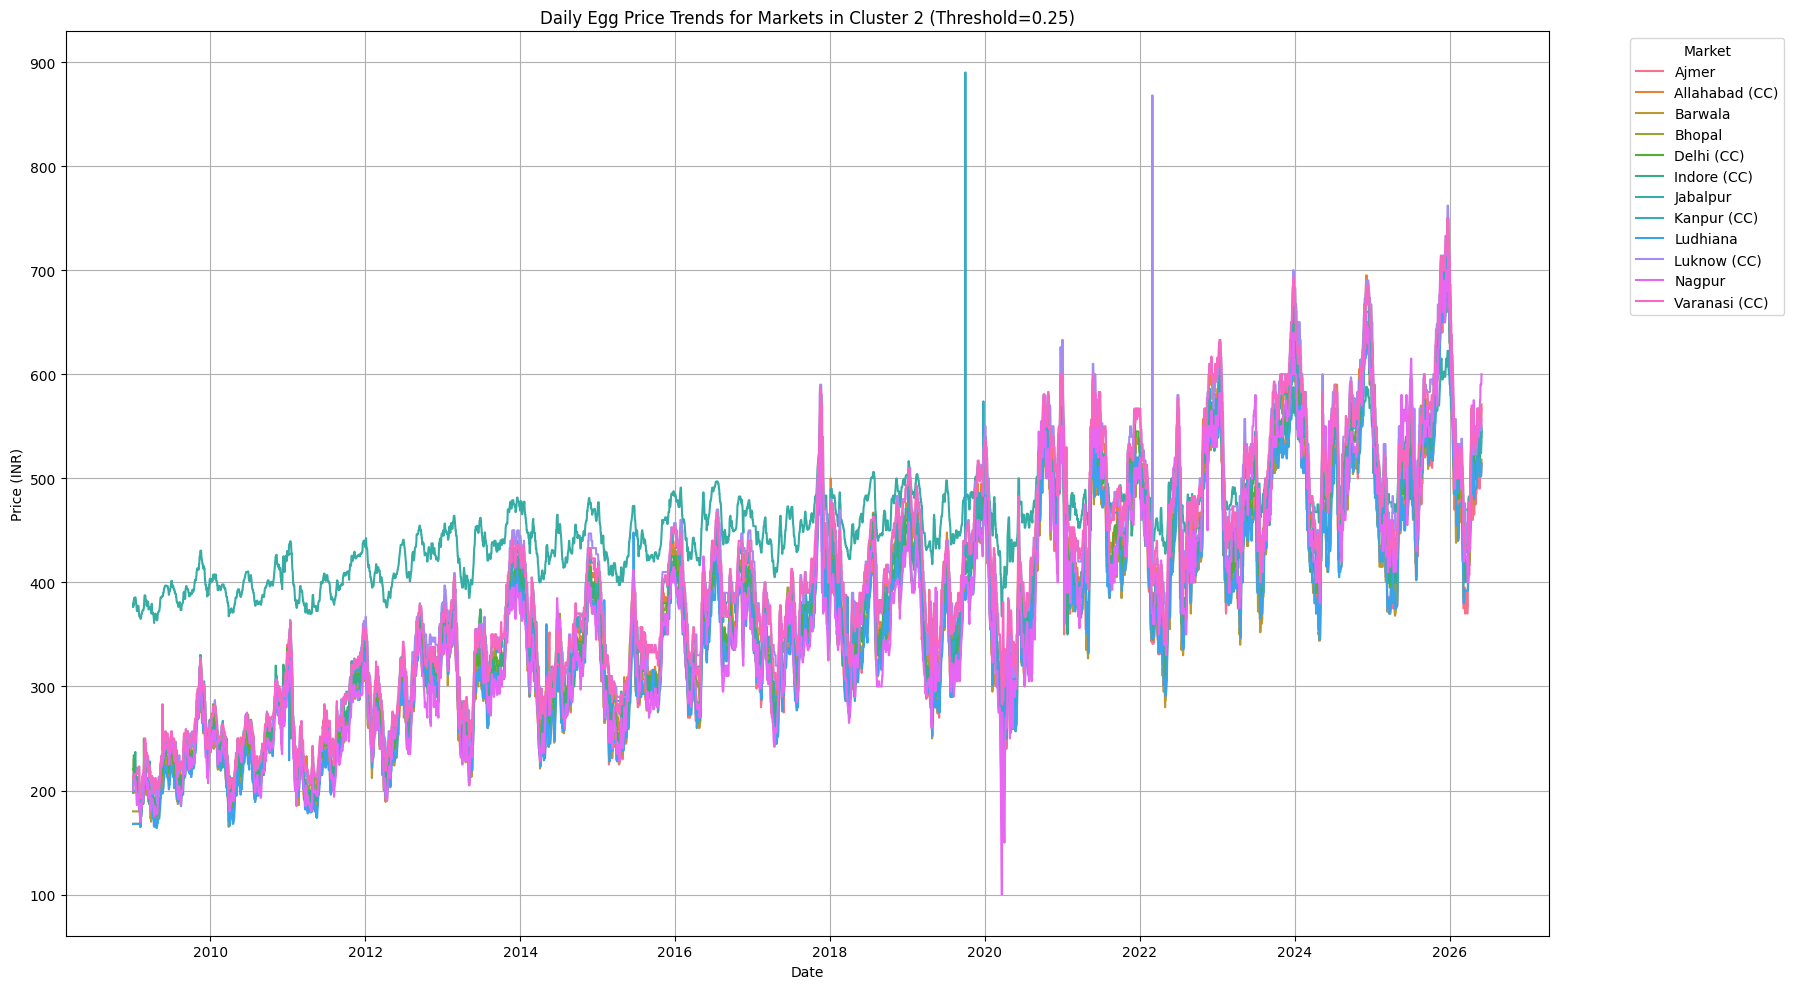

In [43]:
from scipy.cluster.hierarchy import fcluster

# Define a distance threshold to form clusters
# This threshold needs to be chosen based on visual inspection of the dendrogram
# For demonstration, let's pick a threshold that might yield a few distinct clusters.
# A common approach is to look for the largest vertical distance that does not intersect any horizontal lines.
# Based on the dendrogram, a threshold of around 0.2 to 0.4 seems reasonable for initial clusters.
# Adjust this value as needed based on the actual dendrogram generated.
threshold = 0.25 # This value is an estimate, may need adjustment after seeing dendrogram output

clusters = fcluster(linked, threshold, criterion='distance')

# Create a DataFrame to map market names to their cluster IDs
market_cluster_map = pd.DataFrame({'market': correlation_matrix.columns, 'cluster': clusters})

print(f"Number of clusters formed with threshold {threshold}: {market_cluster_map['cluster'].nunique()}")
display(market_cluster_map.sort_values(by='cluster').head())

# Let's pick a cluster (e.g., cluster 1) to visualize its markets' price trends
selected_cluster_id = market_cluster_map['cluster'].value_counts().idxmax() # Pick the largest cluster
selected_markets_in_cluster = market_cluster_map[market_cluster_map['cluster'] == selected_cluster_id]['market'].tolist()

print(f"\nMarkets in the largest cluster (Cluster {selected_cluster_id}): {selected_markets_in_cluster}")

# Filter market_prices_df for selected cluster markets and melt for plotting
cluster_data_melted = market_prices_df[selected_markets_in_cluster].reset_index().melt(id_vars='date', var_name='market', value_name='price_filled')

plt.figure(figsize=(18, 10))
sns.lineplot(data=cluster_data_melted, x='date', y='price_filled', hue='market')
plt.title(f'Daily Egg Price Trends for Markets in Cluster {selected_cluster_id} (Threshold={threshold})')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend(title='Market', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Price Movement of All Markets

Let's visualize the price trends for all markets simultaneously to observe overall patterns and divergences.

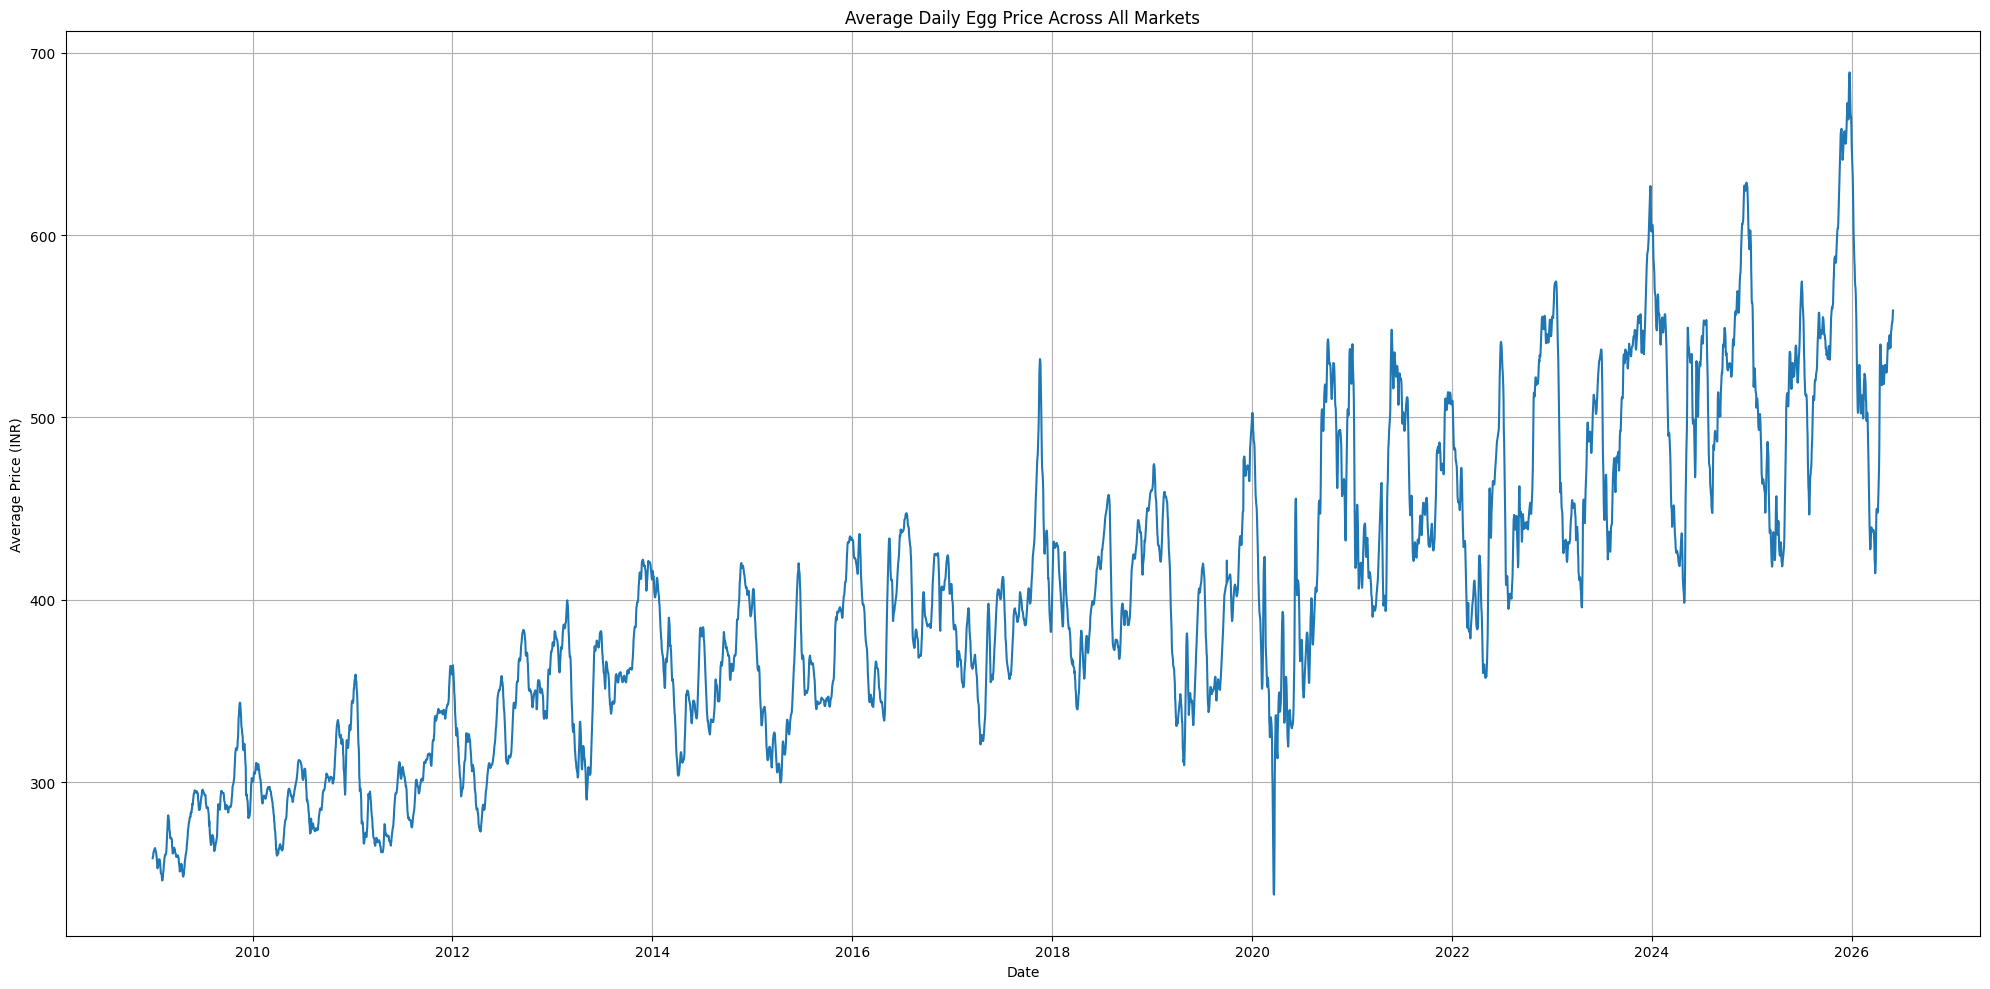

In [44]:
plt.figure(figsize=(20, 10))
# Calculate the average price across all markets for each date
average_all_markets = market_prices_df.mean(axis=1)
sns.lineplot(x=average_all_markets.index, y=average_all_markets.values)
plt.title('Average Daily Egg Price Across All Markets')
plt.xlabel('Date')
plt.ylabel('Average Price (INR)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Market Division by Geographical Quadrant

To analyze price changes from a geographical perspective, we'll assign each market to one of four quadrants: North, South, East, or West. This mapping is based on general geographical knowledge of India. We will then visualize the average daily prices for each quadrant.

In [45]:
# Define a mapping of markets to their respective geographical quadrants
# This is a simplified mapping based on general knowledge and can be refined if specific regions are defined
quadrant_mapping = {
    'Ahmedabad': 'West',
    'Ajmer': 'North',
    'Allahabad (CC)': 'North',
    'Asansole': 'East',
    'Barwala': 'North',
    'Bengaluru (CC)': 'South',
    'Bhopal': 'Central',
    'Brahmapur (OD)': 'East',
    'Burdwan (CC)': 'East',
    'Chennai (CC)': 'South',
    'Chittoor': 'South',
    'Delhi (CC)': 'North',
    'E.Godavari': 'South',
    'Hospet': 'South',
    'Hyderabad': 'South',
    'Indore (CC)': 'Central',
    'Jabalpur': 'Central',
    'Kanpur (CC)': 'North',
    'Kolkata (WB)': 'East',
    'Ludhiana': 'North',
    'Luknow (CC)': 'North',
    'Midnapur (KOL)': 'East',
    'Mumbai (CC)': 'West',
    'Muzaffurpur (CC)': 'East',
    'Mysuru': 'South',
    'Nagpur': 'Central',
    'Namakkal': 'South',
    'Patna': 'East',
    'Pune': 'West',
    'Raipur': 'Central',
    'Ranchi  (CC)': 'East',
    'Surat': 'West',
    'Varanasi (CC)': 'North',
    'Vijayawada': 'South',
    'Vizag': 'South',
    'W.Godavari': 'South',
    'Warangal': 'South'
}

# Melt market_prices_df to long format to easily add quadrant information
# It's important to reset_index() first to keep 'date' as a regular column for melt
market_prices_quadrant_long = market_prices_df.reset_index().melt(
    id_vars='date', var_name='market', value_name='price_filled'
)

# Add the 'quadrant' column to the long format DataFrame
market_prices_quadrant_long['quadrant'] = market_prices_quadrant_long['market'].map(quadrant_mapping)

# Check if any markets were not mapped
unmapped_markets_in_df = market_prices_quadrant_long[market_prices_quadrant_long['quadrant'].isnull()]['market'].unique()
if len(unmapped_markets_in_df) > 0:
    print(f"Warning: The following markets were found in the data but not in the quadrant_mapping: {unmapped_markets_in_df}")

print("Markets categorized by quadrant using 'market_prices_df'. Displaying the first few rows with new 'quadrant' column:")
display(market_prices_quadrant_long.head())

print("\nDistribution of markets by quadrant:")
display(market_prices_quadrant_long['quadrant'].value_counts())

Markets categorized by quadrant using 'market_prices_df'. Displaying the first few rows with new 'quadrant' column:


,date,market,price_filled,quadrant
0,2009-01-01,Ahmedabad,204.0,West
1,2009-01-02,Ahmedabad,206.0,West
2,2009-01-03,Ahmedabad,208.0,West
3,2009-01-04,Ahmedabad,210.0,West
4,2009-01-05,Ahmedabad,210.0,West



Distribution of markets by quadrant:


,count
quadrant,
South,76320
East,50880
North,50880
Central,31800
West,25440


### Average Daily Price by Quadrant

Now, let's calculate the average daily egg price for each quadrant and visualize their trends over time. This will help us observe if there are distinct pricing behaviors across different geographical regions.

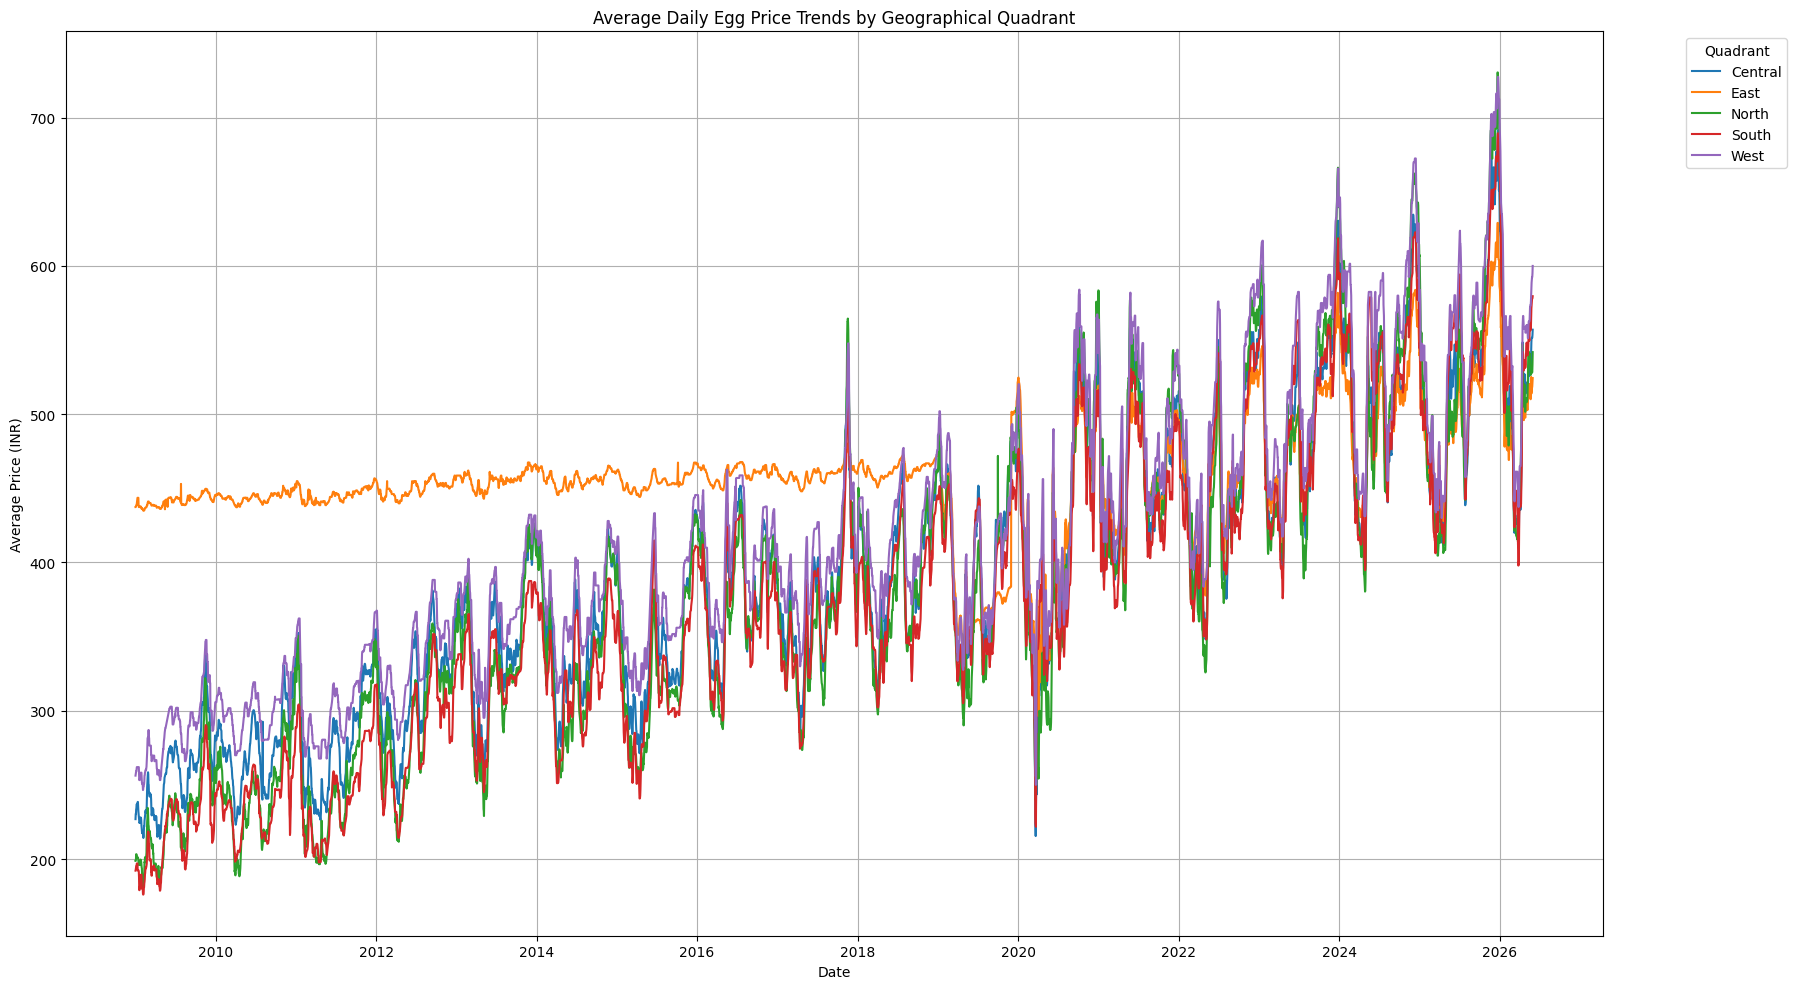

In [46]:
# Calculate the average daily price per quadrant using the long format DataFrame
daily_avg_price_quadrant = market_prices_quadrant_long.groupby(['date', 'quadrant'])['price_filled'].mean().reset_index()

plt.figure(figsize=(18, 10))
sns.lineplot(data=daily_avg_price_quadrant, x='date', y='price_filled', hue='quadrant')
plt.title('Average Daily Egg Price Trends by Geographical Quadrant')
plt.xlabel('Date')
plt.ylabel('Average Price (INR)')
plt.legend(title='Quadrant', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Individual Market Price Trends by Quadrant

To get a more granular view within each region, let's now plot the daily price trends for all individual markets, grouped by their assigned quadrant. This will allow us to observe internal variations and common patterns within each geographical area.


Plotting for West Quadrant...


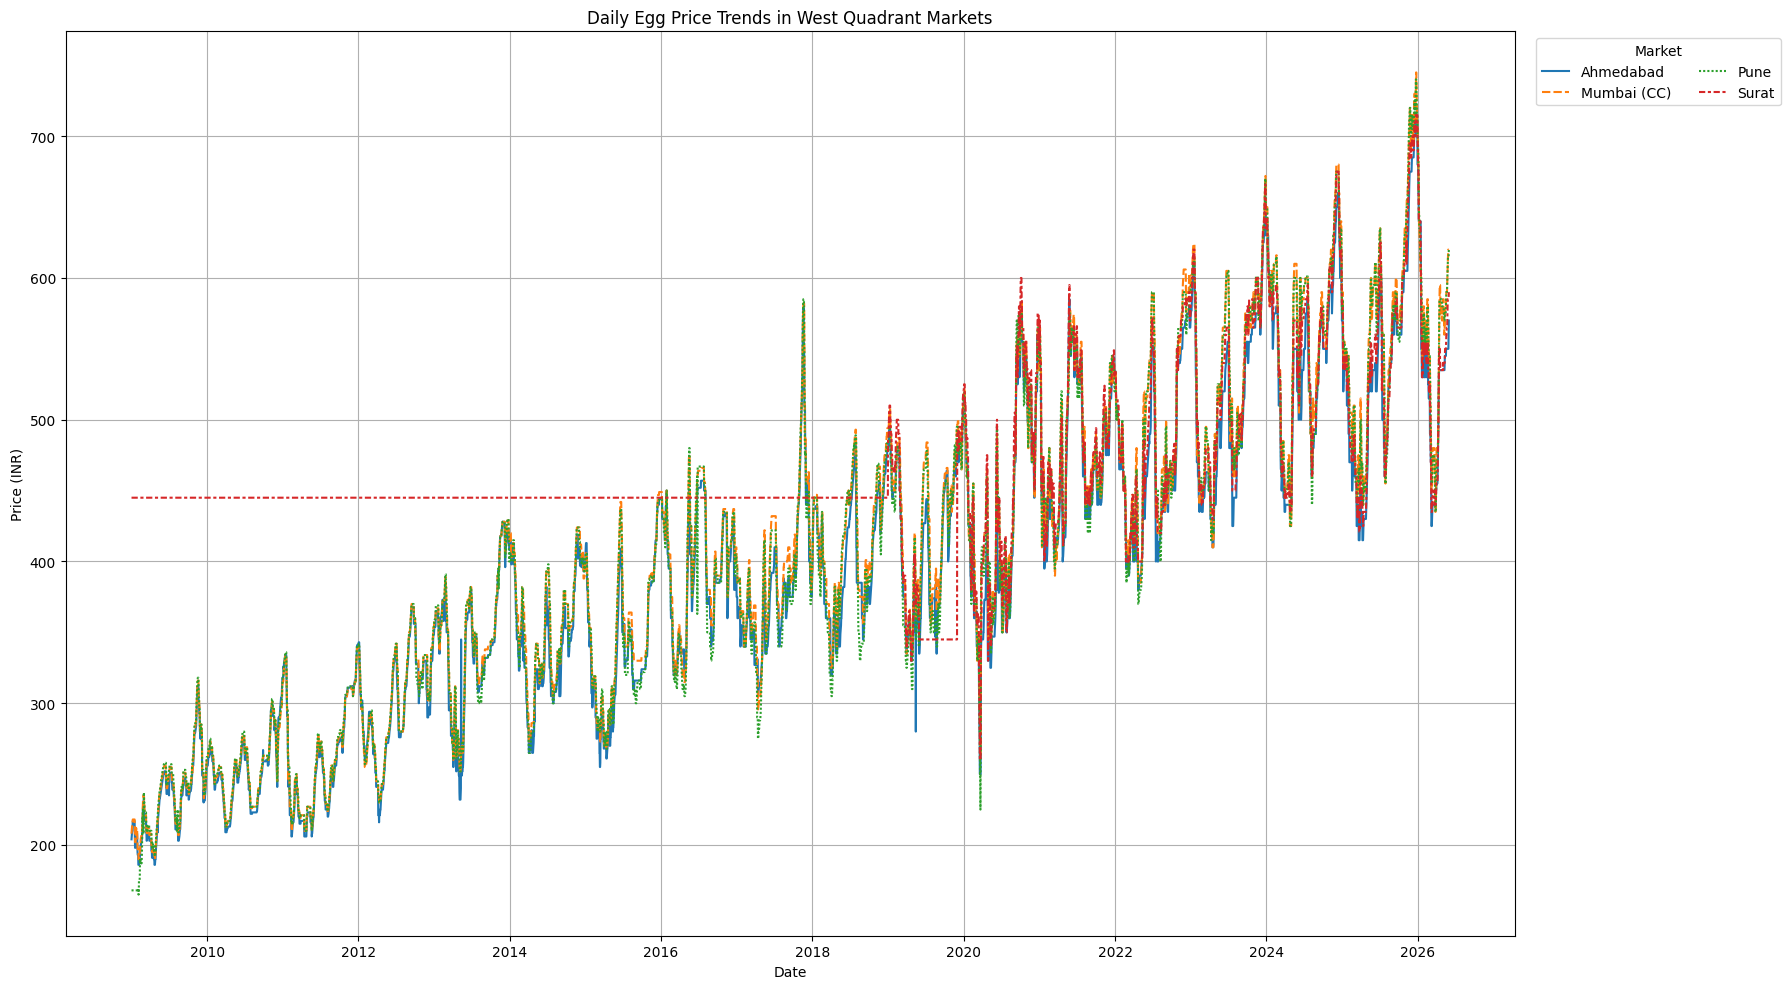


Plotting for North Quadrant...


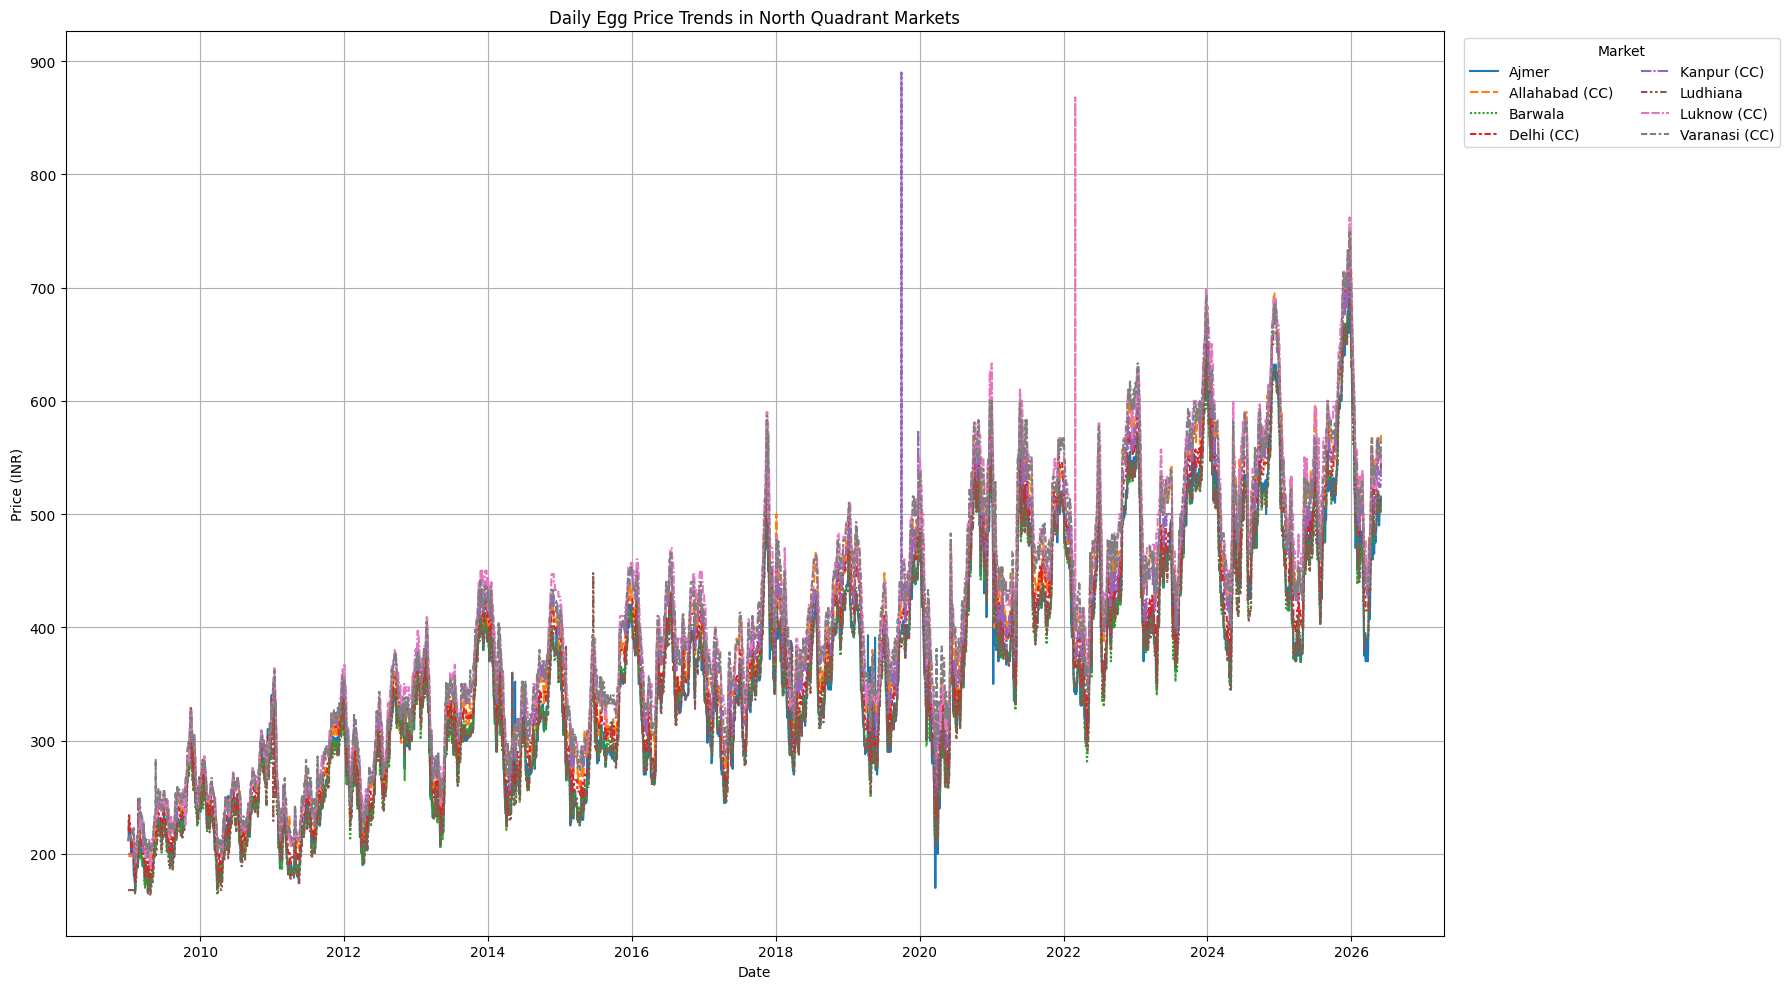


Plotting for East Quadrant...


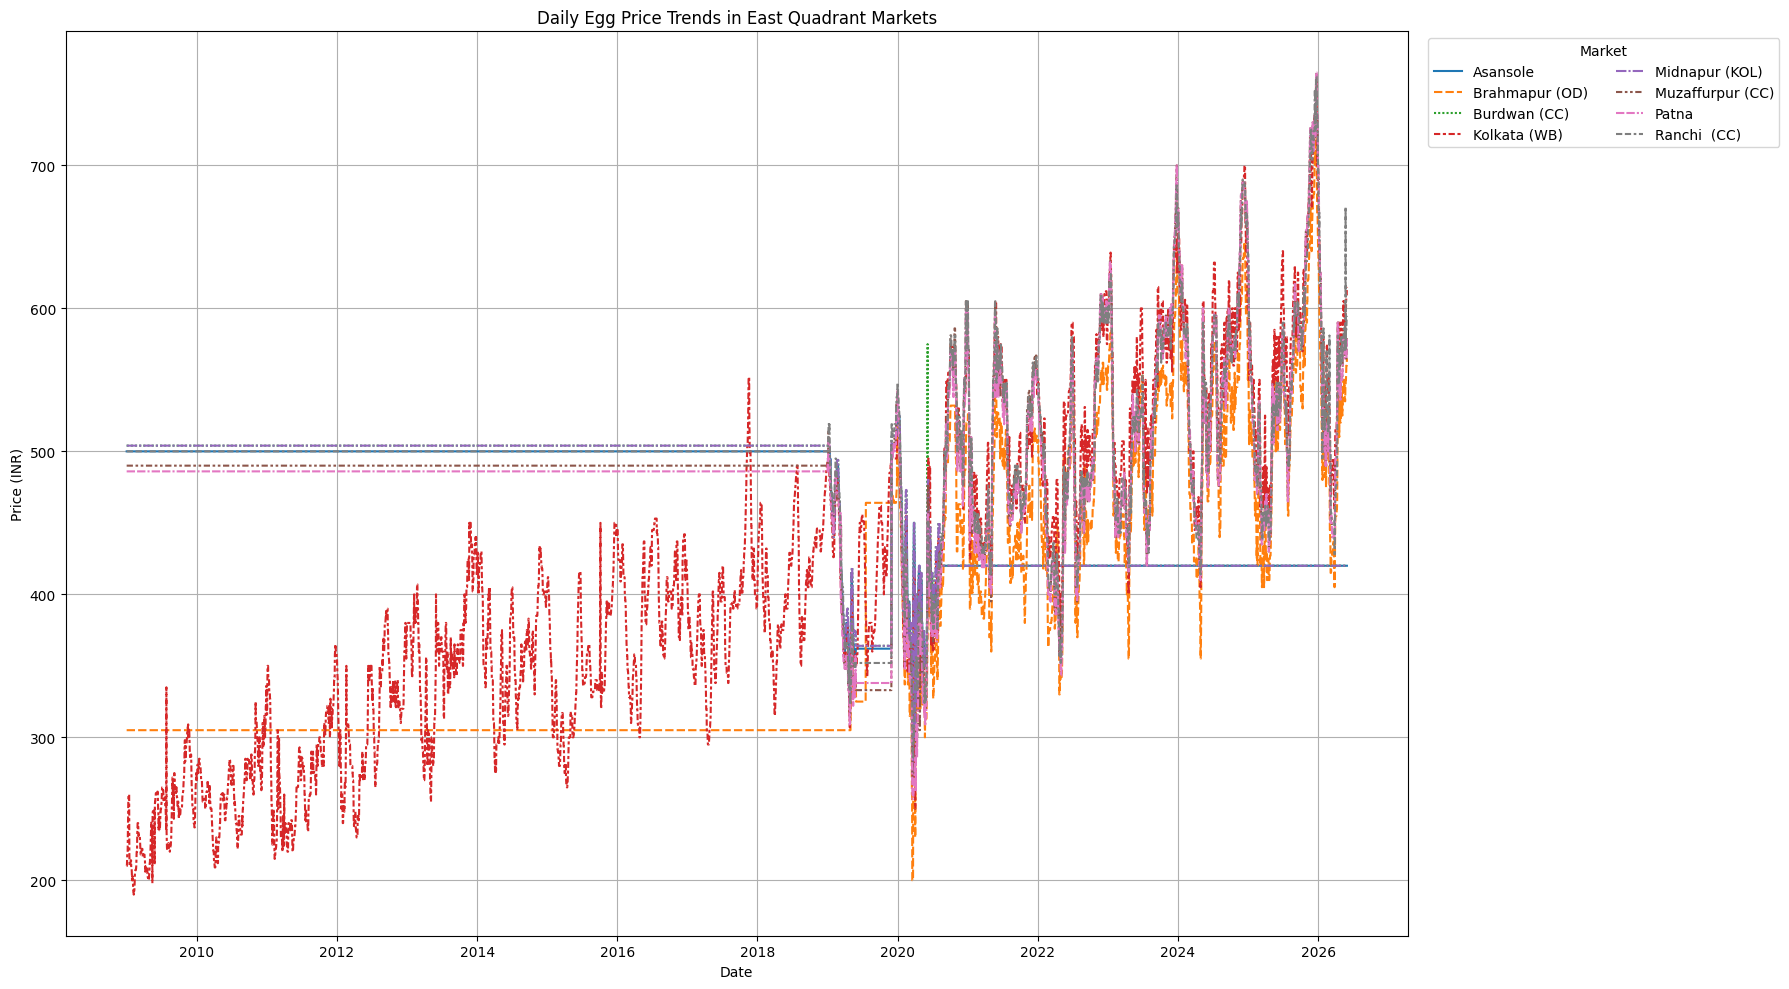


Plotting for South Quadrant...


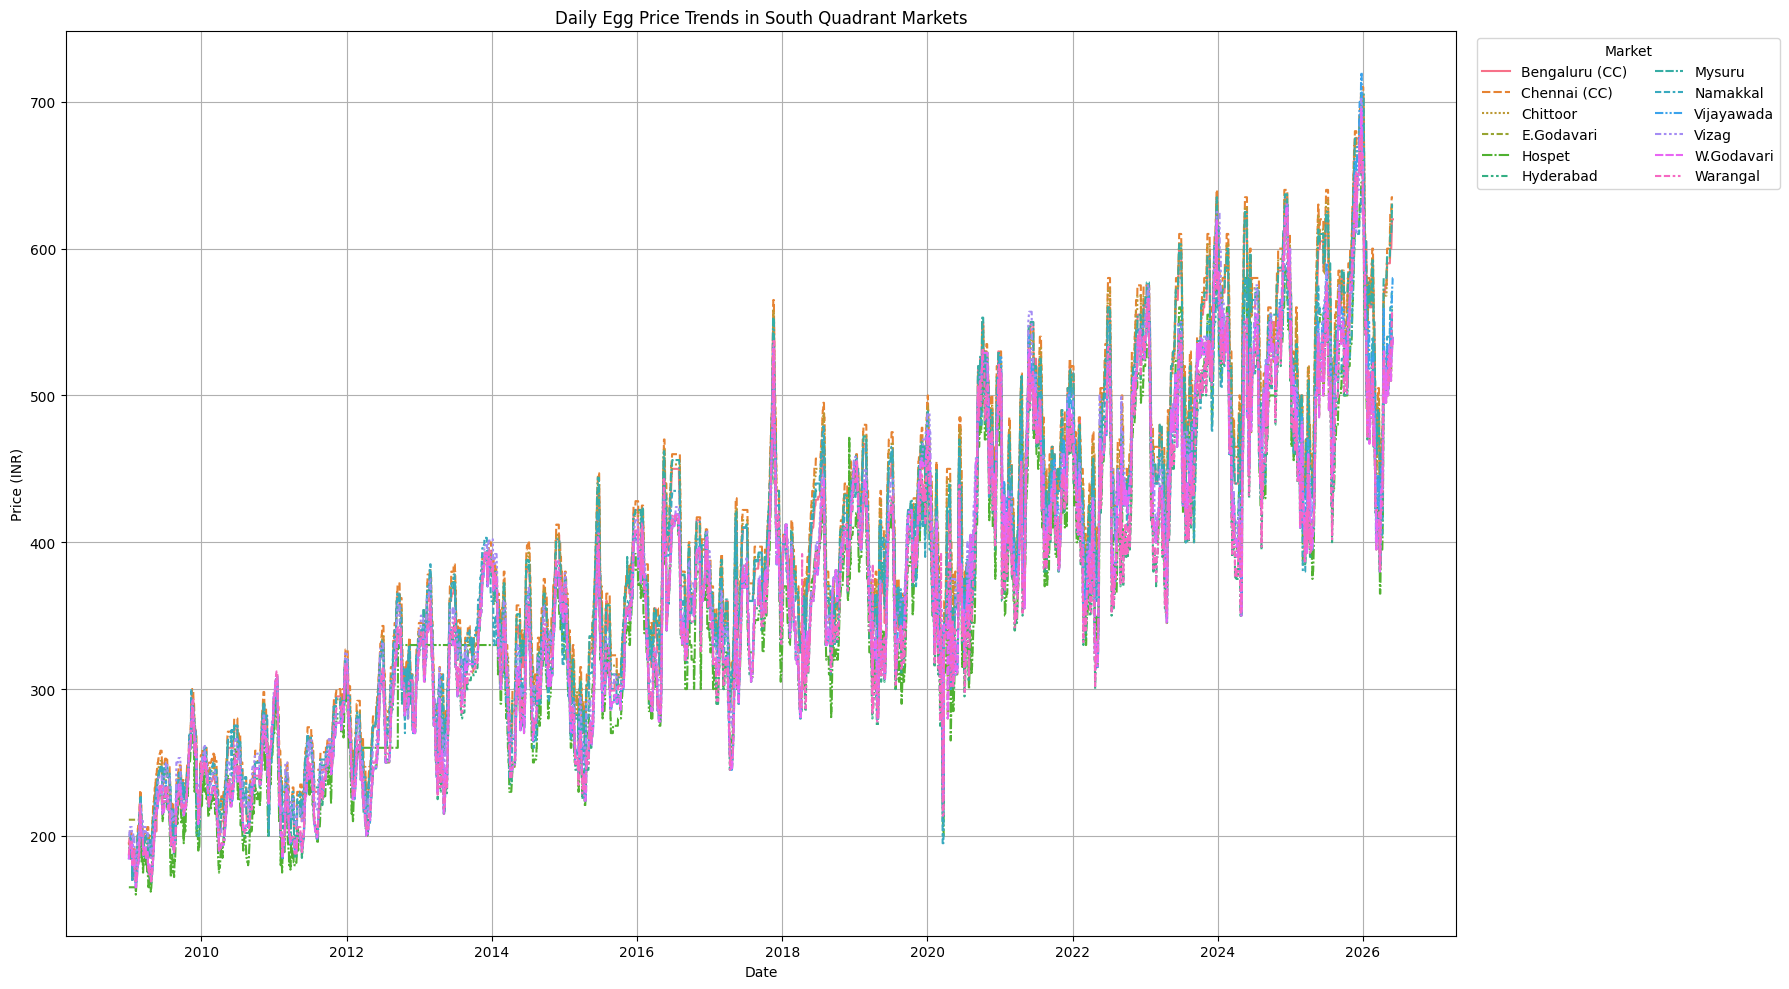


Plotting for Central Quadrant...


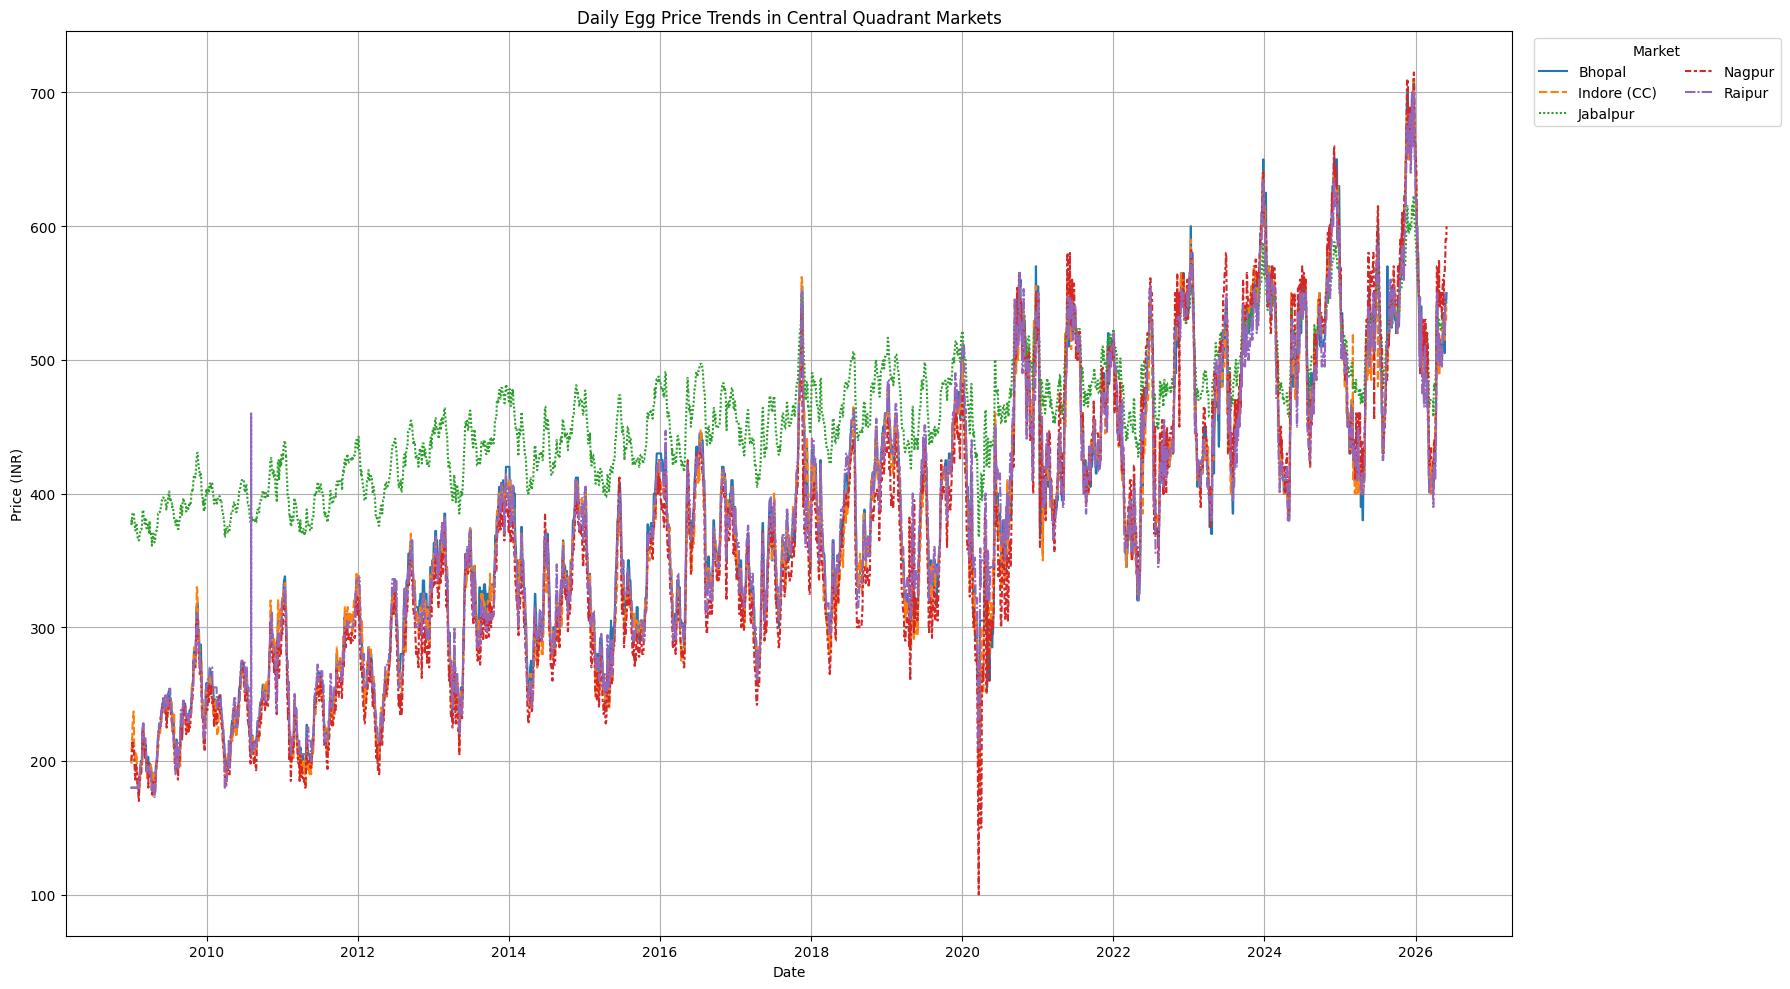

In [47]:
# Get unique quadrants from the market_prices_quadrant_long DataFrame
quadrants = market_prices_quadrant_long['quadrant'].dropna().unique()

for quadrant in quadrants:
    print(f"\nPlotting for {quadrant} Quadrant...")
    # Filter market_prices_quadrant_long for the current quadrant
    quadrant_markets_long_data = market_prices_quadrant_long[market_prices_quadrant_long['quadrant'] == quadrant]

    # Get the unique markets in this quadrant
    markets_in_quadrant = quadrant_markets_long_data['market'].unique()

    # If there are markets in the quadrant, plot their trends
    if len(markets_in_quadrant) > 0:
        # Pivot the long format data back to wide format for plotting
        quadrant_pivot_df = quadrant_markets_long_data.pivot_table(index='date', columns='market', values='price_filled')

        plt.figure(figsize=(18, 10))
        sns.lineplot(data=quadrant_pivot_df)
        plt.title(f'Daily Egg Price Trends in {quadrant} Quadrant Markets')
        plt.xlabel('Date')
        plt.ylabel('Price (INR)')
        plt.legend(title='Market', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=2)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping plotting for {quadrant} quadrant as it contains no markets.")

### Price Volatility by Geographical Quadrant

Now, let's analyze and compare the price volatility (standard deviation) across the different geographical quadrants. This will highlight which regions experience more stable or fluctuating egg prices.

### Identifying Volatile Markets within the Central Quadrant

Given that the 'Central' quadrant shows the highest price volatility, let's drill down to identify which specific markets within this quadrant are driving this trend. We'll calculate the standard deviation of prices for each market in the 'Central' region and visualize them.

Price Volatility for Markets in the Central Quadrant:


,market,price_filled
0,Nagpur,112.027962
1,Indore (CC),105.806162
2,Bhopal,105.065137
3,Raipur,103.231167
4,Jabalpur,49.763003


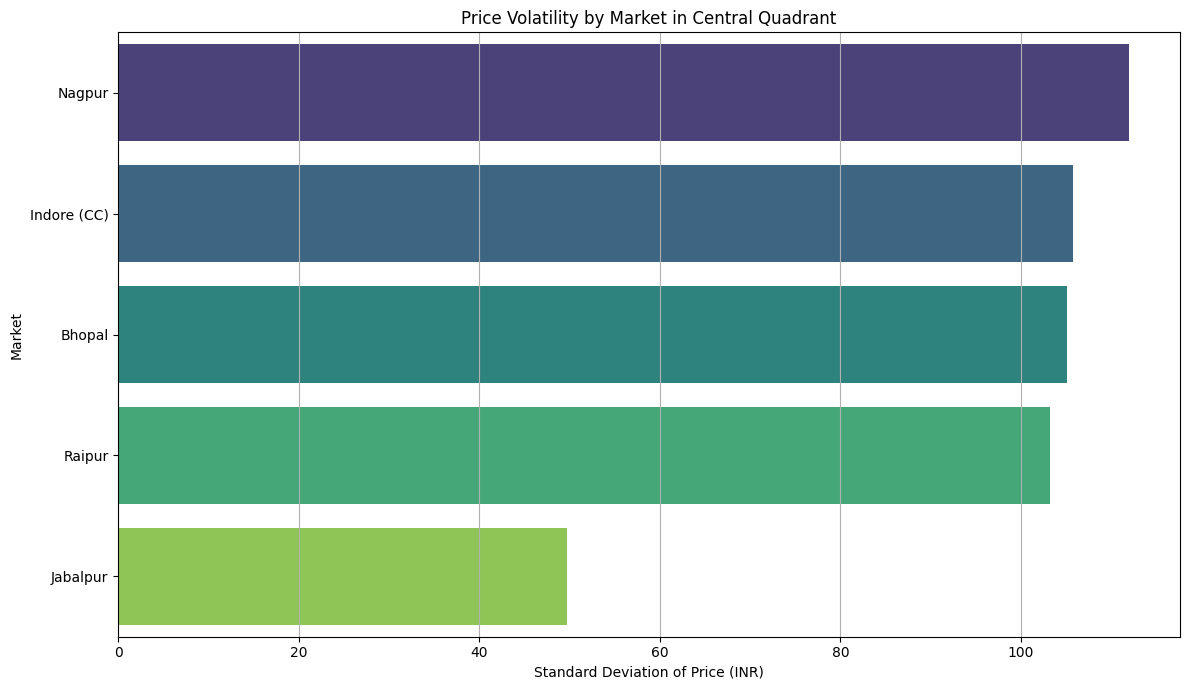

In [48]:
# Filter data for the Central quadrant using market_prices_quadrant_long
central_quadrant_long_data = market_prices_quadrant_long[market_prices_quadrant_long['quadrant'] == 'Central']

# Calculate volatility (standard deviation) for each market in the Central quadrant
central_market_volatility = central_quadrant_long_data.groupby('market')['price_filled'].std().sort_values(ascending=False).reset_index()

print("Price Volatility for Markets in the Central Quadrant:")
display(central_market_volatility)

# Visualize the volatility for markets in the Central quadrant
plt.figure(figsize=(12, 7))
sns.barplot(x='price_filled', y='market', data=central_market_volatility, palette='viridis')
plt.title('Price Volatility by Market in Central Quadrant')
plt.xlabel('Standard Deviation of Price (INR)')
plt.ylabel('Market')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Price Trends for Most Volatile Central Markets

To further understand the high volatility in these markets, let's visualize their daily price trends.

Visualizing price trends for the top 3 most volatile markets in the Central Quadrant: ['Nagpur', 'Indore (CC)', 'Bhopal']


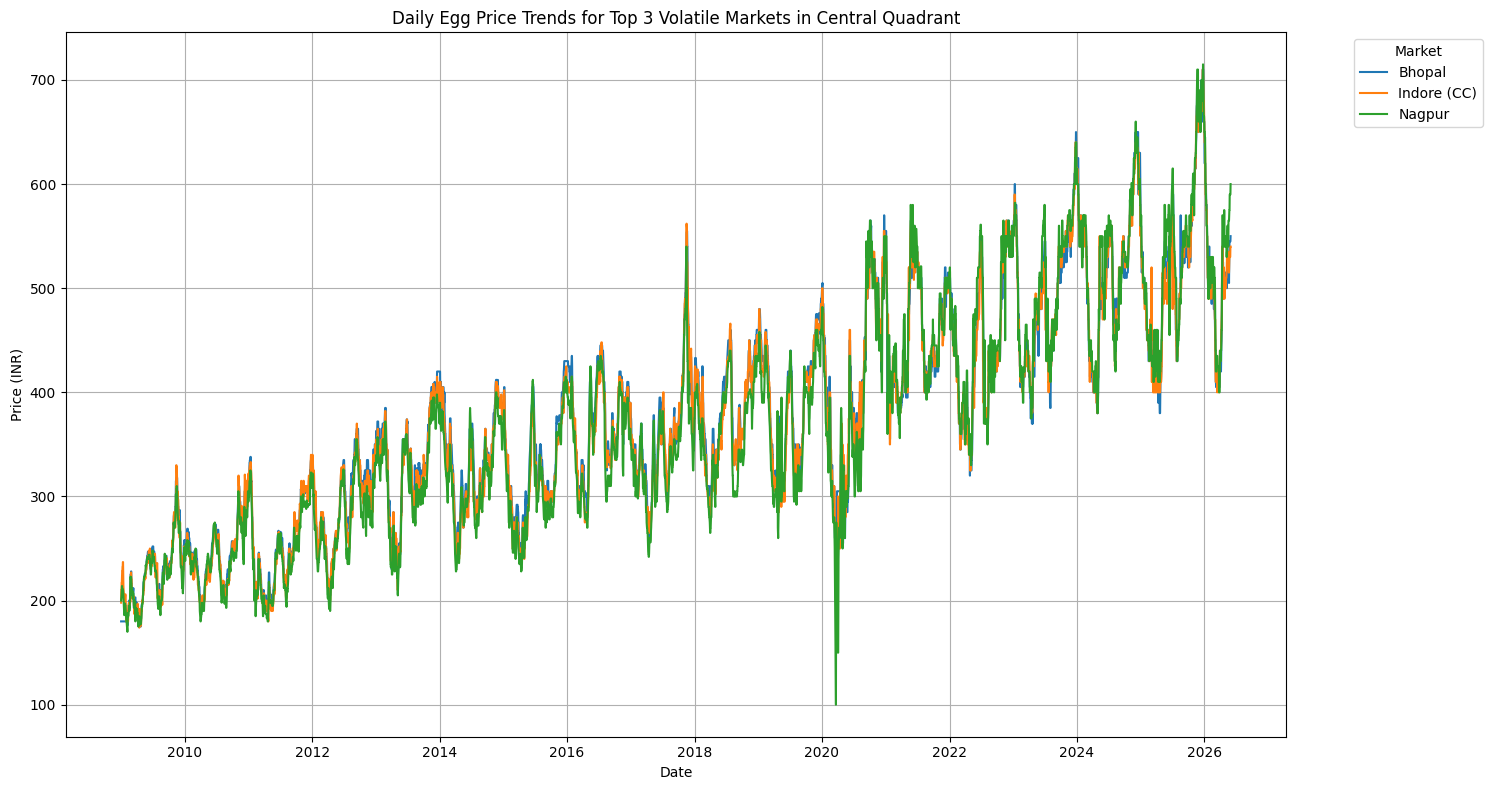

In [51]:
# Get the top N most volatile markets from the Central quadrant (e.g., top 3 or 5)
# Based on the previous plot, Jabalpur, Bhopal, and Indore (CC) seem to be the highest.
num_top_volatile_markets = 3 # Adjust as needed
top_volatile_central_markets = central_market_volatility['market'].head(num_top_volatile_markets).tolist()

print(f"Visualizing price trends for the top {num_top_volatile_markets} most volatile markets in the Central Quadrant: {top_volatile_central_markets}")

# Filter the market_prices_quadrant_long for these specific markets
top_volatile_central_data = market_prices_quadrant_long[market_prices_quadrant_long['market'].isin(top_volatile_central_markets)]

plt.figure(figsize=(15, 8))
sns.lineplot(data=top_volatile_central_data, x='date', y='price_filled', hue='market')
plt.title(f'Daily Egg Price Trends for Top {num_top_volatile_markets} Volatile Markets in Central Quadrant')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend(title='Market', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

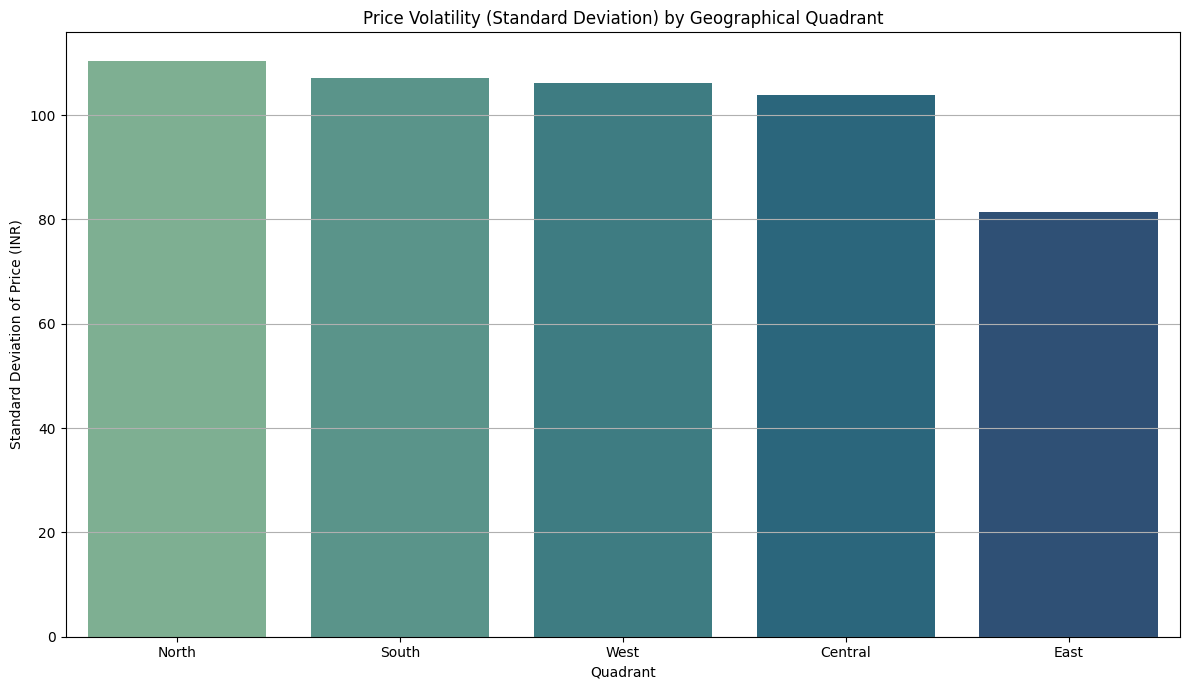

In [52]:
quadrant_volatility = market_prices_quadrant_long.groupby('quadrant')['price_filled'].std().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='quadrant', y='price_filled', data=quadrant_volatility, palette='crest')
plt.title('Price Volatility (Standard Deviation) by Geographical Quadrant')
plt.xlabel('Quadrant')
plt.ylabel('Standard Deviation of Price (INR)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Year-over-Year Percentage Change in Prices

To understand the annual growth or decline in egg prices, let's calculate the year-over-year percentage change based on the average yearly prices we've already computed.

In [53]:
# Calculate the year-over-year percentage change
yearly_avg_price['price_change_pct'] = yearly_avg_price['price_filled'].pct_change() * 100

print("Year-over-Year Percentage Change in Average Egg Prices:")
display(yearly_avg_price)

Year-over-Year Percentage Change in Average Egg Prices:


,year,price_filled,price_change_pct
0,2009,283.905371,NaN
1,2010,298.895350,5.279921
2,2011,304.169178,1.764440
3,2012,333.227064,9.553199
4,2013,365.335256,9.635530
5,2014,366.300000,0.264071
6,2015,359.667628,-1.810639
7,2016,398.784728,10.875902
8,2017,392.099892,-1.676302
9,2018,405.952812,3.533008


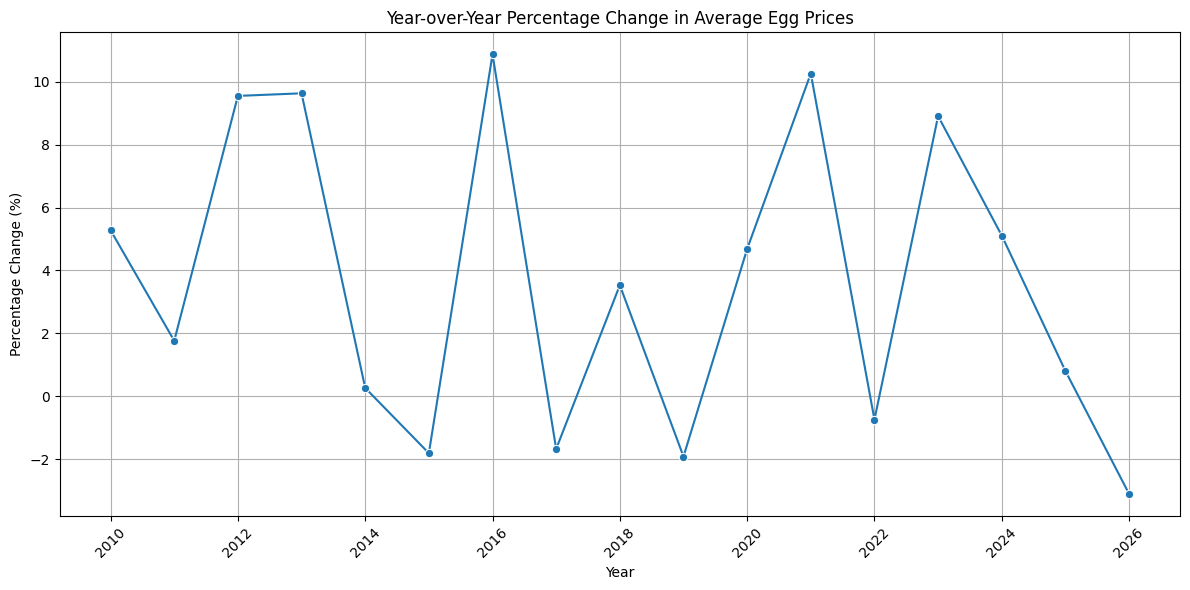

In [54]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='price_change_pct', data=yearly_avg_price, marker='o')
plt.title('Year-over-Year Percentage Change in Average Egg Prices')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Year-over-Year Percentage Change by Quadrant

To understand how price changes differ across geographical regions, let's calculate the year-over-year percentage change for each quadrant and visualize it.

In [55]:
# Extract year from the date column
market_prices_quadrant_long['year'] = market_prices_quadrant_long['date'].dt.year

# Calculate the average annual price for each quadrant
yearly_avg_price_by_quadrant = market_prices_quadrant_long.groupby(['year', 'quadrant'])['price_filled'].mean().reset_index()

# Calculate the year-over-year percentage change for each quadrant
yearly_avg_price_by_quadrant['price_change_pct'] = yearly_avg_price_by_quadrant.groupby('quadrant')['price_filled'].pct_change() * 100

print("Year-over-Year Percentage Change in Average Egg Prices by Quadrant:")
display(yearly_avg_price_by_quadrant.head())
display(yearly_avg_price_by_quadrant.tail())

Year-over-Year Percentage Change in Average Egg Prices by Quadrant:


,year,quadrant,price_filled,price_change_pct
0,2009,Central,256.788493,NaN
1,2009,East,441.492808,NaN
2,2009,North,227.248288,NaN
3,2009,South,218.612900,NaN
4,2009,West,285.814384,NaN


,year,quadrant,price_filled,price_change_pct
85,2026,Central,504.729139,-3.817850
86,2026,East,492.015728,-2.824658
87,2026,North,505.543874,-4.273978
88,2026,South,516.167219,-2.588516
89,2026,West,541.763245,-2.291368


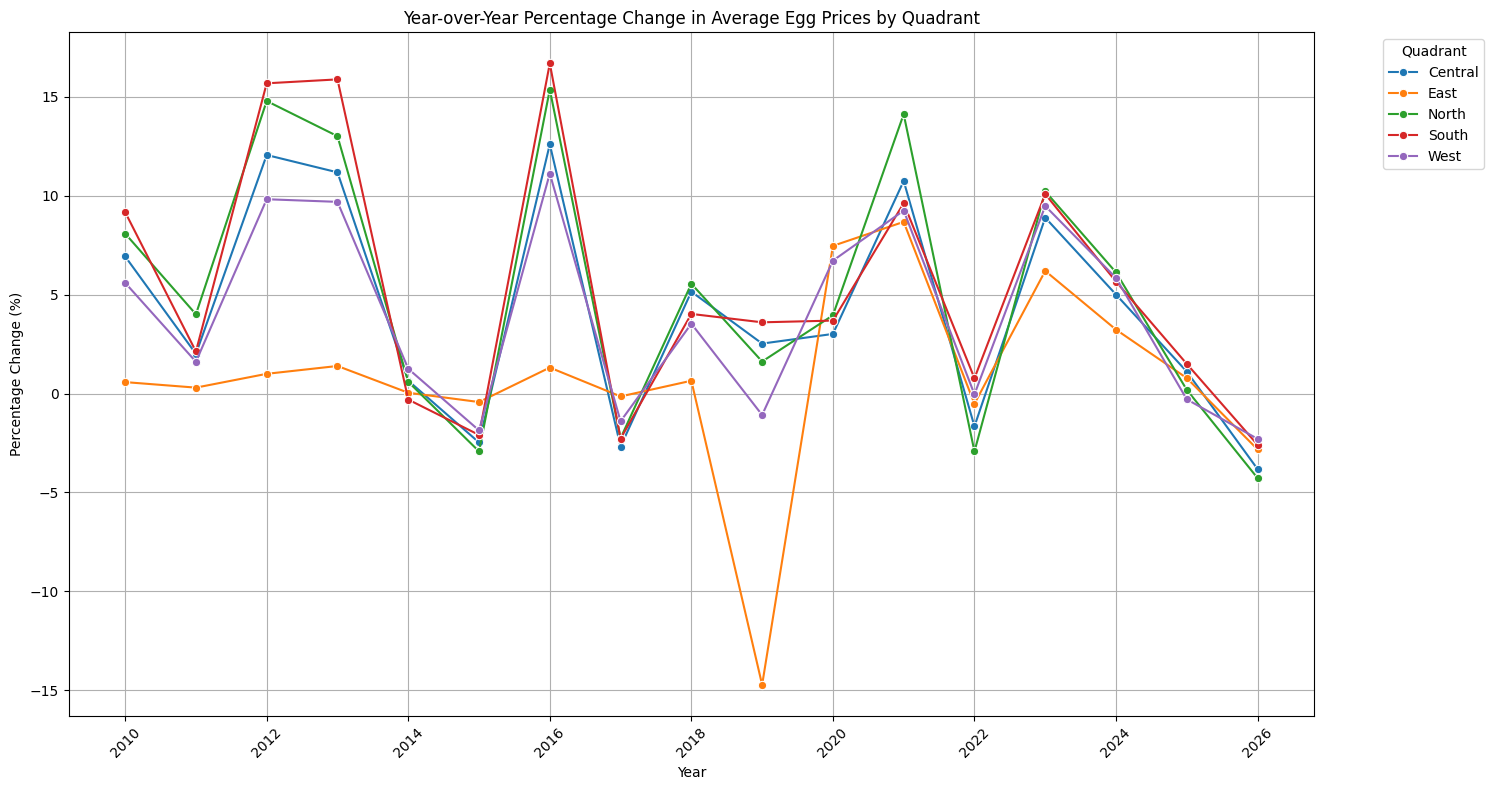

In [56]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='year', y='price_change_pct', hue='quadrant', data=yearly_avg_price_by_quadrant, marker='o')
plt.title('Year-over-Year Percentage Change in Average Egg Prices by Quadrant')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Quadrant', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()